Code 24.3.26

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn ptflops -q

In [ ]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================
# !pip install torch torchvision scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from ptflops import get_model_complexity_info


# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD DATASET (SAFE VERSION)
# =========================================================
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

# remove any NaN rows
train_df = train_df.dropna()
test_df = test_df.dropna()

# split features and labels
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# convert labels to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# convert to tensors
X_train = torch.tensor(X_train.reshape(-1,1,187), dtype=torch.float32)
X_test = torch.tensor(X_test.reshape(-1,1,187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Unique labels:", torch.unique(y_train))

# =========================================================
# DATASET CLASS
# =========================================================
class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ECGDataset(X_train,y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(ECGDataset(X_test,y_test), batch_size=64)

# =========================================================
# MODEL 1 : TinyCNN
# =========================================================
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN,self).__init__()
        self.conv1 = nn.Conv1d(1,8,5)
        self.conv2 = nn.Conv1d(8,16,5)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(16,5)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 2 : LightweightCNN
# =========================================================
class LightweightCNN(nn.Module):
    def __init__(self):
        super(LightweightCNN,self).__init__()
        self.conv1 = nn.Conv1d(1,16,5)
        self.conv2 = nn.Conv1d(16,32,5)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(32,5)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# TRAIN FUNCTION
# =========================================================
def train_model(model, epochs=25):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for inputs,labels in train_loader:

            inputs,labels = inputs.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return model

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate(model, loader):

    model.eval()

    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for inputs,labels in loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs,dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels,all_preds)
    f1 = f1_score(all_labels,all_preds,average='weighted')

    return acc,f1,all_labels,all_preds

# =========================================================
# Simple Baseline CNN
# =========================================================

class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1,16,5)
        self.pool = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16,32,5)

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(32,5)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = self.gap(x)
        x = x.squeeze(-1)

        return self.fc(x)


# =========================================================
# TRAIN MODELS
# =========================================================
print("\nTraining TinyCNN\n")
tiny_model = train_model(TinyCNN(),epochs=25)

print("\nTraining LightweightCNN\n")
light_model = train_model(LightweightCNN(),epochs=25)

print("\nBasic CNN\n")
basic_model = train_model(BasicCNN(), 25)


# =========================================================
# CLEAN DATA RESULTS
# =========================================================
# tiny_acc,tiny_f1,labels,preds = evaluate(tiny_model,test_loader)
# light_acc,light_f1,_,_ = evaluate(light_model,test_loader)

tiny_acc, tiny_f1, tiny_labels, tiny_preds = evaluate(tiny_model, test_loader)
light_acc, light_f1, light_labels, light_preds = evaluate(light_model, test_loader)
basic_acc, basic_f1, _, _ = evaluate(basic_model, test_loader)

print("\nTinyCNN Accuracy:",tiny_acc)
print("TinyCNN F1:",tiny_f1)

print("\nLightweightCNN Accuracy:",light_acc)
print("LightweightCNN F1:",light_f1)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(tiny_labels,tiny_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("TinyCNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Define the AAMI labels
aami_labels = ['N', 'S', 'V', 'F', 'Q']

# CONFUSION MATRIX - LightweightCNN (Improved version)
cm = confusion_matrix(light_labels, light_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=aami_labels, yticklabels=aami_labels)

plt.title("LightweightCNN Confusion Matrix (AAMI Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================================
# NOISE ROBUSTNESS TEST (FIXED VERSION)
# =========================================================
def add_noise(data, level):
    noise = level * torch.randn_like(data)
    return data + noise

noise_levels = [0, 0.05, 0.1, 0.15, 0.2] # Added more points for a smoother curve
tiny_results = []
light_results = []

print("\nRunning Noise Robustness Test...")

for nl in noise_levels:
    noisy_X = add_noise(X_test, nl)
    noisy_loader = DataLoader(ECGDataset(noisy_X, y_test), batch_size=64)

    acc1, _, _, _ = evaluate(tiny_model, noisy_loader)
    acc2, _, _, _ = evaluate(light_model, noisy_loader)

    tiny_results.append(acc1)
    light_results.append(acc2)

# Create a fresh figure for this plot
plt.figure(figsize=(10, 6))

# Use different colors, markers, and line styles to ensure visibility
plt.plot(noise_levels, tiny_results, 'b-o', label="TinyCNN (789 params)", linewidth=2, markersize=8)
plt.plot(noise_levels, light_results, 'g--s', label="LightweightCNN (2853 params)", linewidth=2, markersize=8)

plt.xlabel("Noise Level ($\sigma$)", fontsize=12)
plt.ylabel("Classification Accuracy", fontsize=12)
plt.title("Model Robustness to Gaussian Noise", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.7) 

plt.show()

# =========================================================
# FLOPS Computation Function
# =========================================================

def compute_flops(model):
    with torch.cuda.device(0 if torch.cuda.is_available() else -1):
        macs, params = get_model_complexity_info(
            model,
            (1,187),
            as_strings=False,
            print_per_layer_stat=False
        )
    return macs

# ========================================================
# Compute Cost Function
# ========================================================

def compute_cost(flops, time):
    return flops * time


# =========================================================
# PARAMETER COUNT
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTinyCNN Parameters:",count_parameters(tiny_model))
print("LightweightCNN Parameters:",count_parameters(light_model))

# =========================================================
# FLOPS Comparison
# =========================================================

plt.figure()
plt.bar(df["Model"], df["FLOPs"])
plt.title("FLOPs Comparison")
plt.ylabel("FLOPs")
plt.xticks(rotation=30)
plt.show()


# =========================================================
# Accuracy vs Model
# =========================================================
plt.figure()
plt.bar(df["Model"], df["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# =========================================================
# Computation Cost Graph
# =========================================================
plt.figure()
plt.bar(df["Model"], df["Computation Cost"])
plt.title("Computation Cost Comparison")
plt.ylabel("Cost")
plt.xticks(rotation=30)
plt.show()


# =========================================================
# Accuracy vs FLOPS
# =========================================================

plt.figure()

for i in range(len(df)):
    plt.scatter(df["FLOPs"][i], df["Accuracy"][i])
    plt.text(df["FLOPs"][i], df["Accuracy"][i], df["Model"][i])

plt.xlabel("FLOPs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Complexity Trade-off")
plt.grid()

plt.show()


# =========================================================
# INFERENCE TIME
# =========================================================
def measure_inference(model):

    model.eval()

    start=time.time()

    with torch.no_grad():

        model(X_test.to(device))

    end=time.time()

    return end-start

print("\nTinyCNN Inference Time:",measure_inference(tiny_model))
print("LightweightCNN Inference Time:",measure_inference(light_model))


<>:285: SyntaxWarning: invalid escape sequence '\s'
<>:285: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_418/2396078354.py:285: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Noise Level ($\sigma$)", fontsize=12)


Using device: cpu
Train shape: torch.Size([87554, 1, 187])
Test shape: torch.Size([21892, 1, 187])
Unique labels: tensor([0, 1, 2, 3, 4])

Training TinyCNN

Epoch 1/25 | Loss: 911.9128
Epoch 2/25 | Loss: 842.3801
Epoch 3/25 | Loss: 831.7942
Epoch 4/25 | Loss: 818.3511
Epoch 5/25 | Loss: 799.8150
Epoch 6/25 | Loss: 779.2286
Epoch 7/25 | Loss: 759.2462
Epoch 8/25 | Loss: 739.9406
Epoch 9/25 | Loss: 720.6745
Epoch 10/25 | Loss: 701.4587
Epoch 11/25 | Loss: 675.4443
Epoch 12/25 | Loss: 649.0271
Epoch 13/25 | Loss: 622.2938
Epoch 14/25 | Loss: 598.3516
Epoch 15/25 | Loss: 578.4581
Epoch 16/25 | Loss: 560.8967
Epoch 17/25 | Loss: 546.2001
Epoch 18/25 | Loss: 533.5108
Epoch 19/25 | Loss: 522.5186
Epoch 20/25 | Loss: 511.2923
Epoch 21/25 | Loss: 500.6694
Epoch 22/25 | Loss: 489.3005
Epoch 23/25 | Loss: 477.2112
Epoch 24/25 | Loss: 466.5255
Epoch 25/25 | Loss: 458.1750

Training LightweightCNN

Epoch 1/25 | Loss: 898.8074
Epoch 2/25 | Loss: 818.6385
Epoch 3/25 | Loss: 718.8777
Epoch 4/25 | Loss

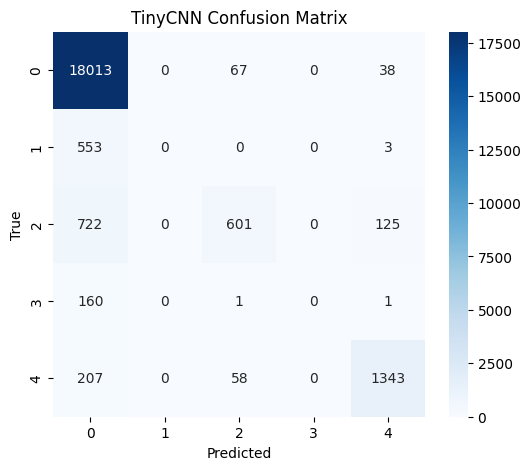

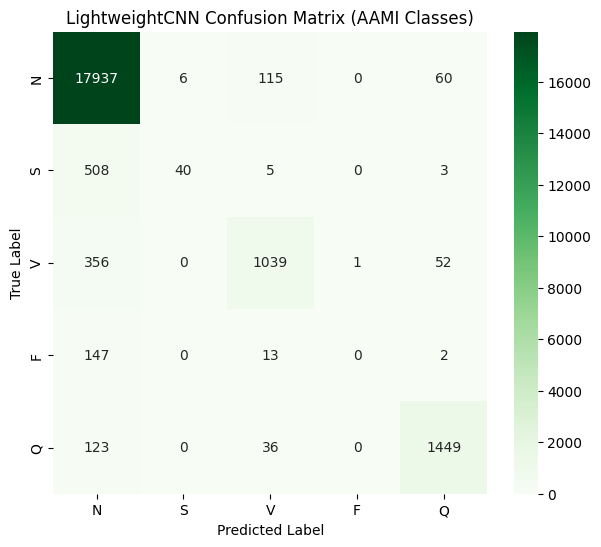


Running Noise Robustness Test...


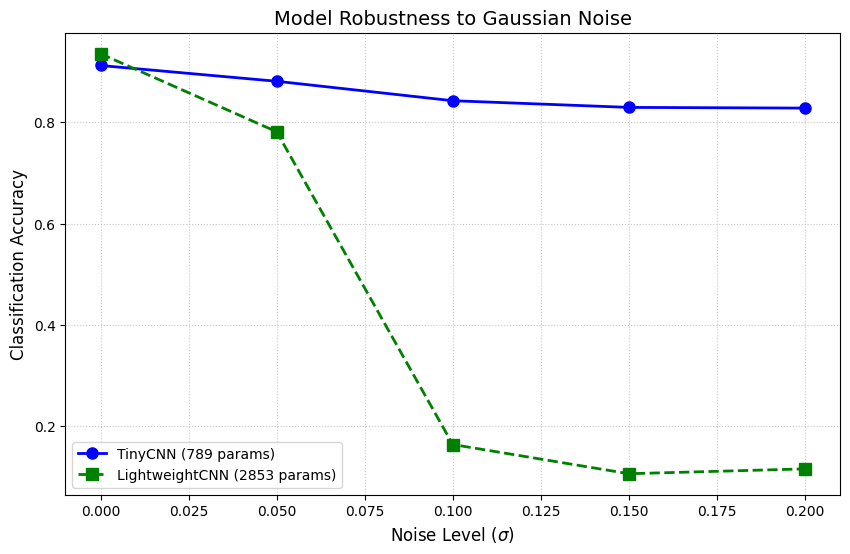


TinyCNN Parameters: 789
LightweightCNN Parameters: 2853

TinyCNN Inference Time: 1.4326298236846924
LightweightCNN Inference Time: 2.086642265319824


In [ ]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================
# !pip install torch torchvision scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD DATASET (SAFE VERSION)
# =========================================================
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

# remove any NaN rows
train_df = train_df.dropna()
test_df = test_df.dropna()

# split features and labels
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# convert labels to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# convert to tensors
X_train = torch.tensor(X_train.reshape(-1,1,187), dtype=torch.float32)
X_test = torch.tensor(X_test.reshape(-1,1,187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Unique labels:", torch.unique(y_train))

# =========================================================
# DATASET CLASS
# =========================================================
class ECGDataset(Dataset):
    def __init__(self,X,y):
        self.X=X
        self.y=y
    def __len__(self):
        return len(self.X)
    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ECGDataset(X_train,y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(ECGDataset(X_test,y_test), batch_size=64)

# =========================================================
# MODEL 1 : TinyCNN
# =========================================================
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN,self).__init__()
        self.conv1 = nn.Conv1d(1,8,5)
        self.conv2 = nn.Conv1d(8,16,5)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(16,5)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 2 : LightweightCNN
# =========================================================
class LightweightCNN(nn.Module):
    def __init__(self):
        super(LightweightCNN,self).__init__()
        self.conv1 = nn.Conv1d(1,16,5)
        self.conv2 = nn.Conv1d(16,32,5)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(32,5)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# TRAIN FUNCTION
# =========================================================
def train_model(model, epochs=25):

    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for inputs,labels in train_loader:

            inputs,labels = inputs.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return model

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate(model, loader):

    model.eval()

    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for inputs,labels in loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs,dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels,all_preds)
    f1 = f1_score(all_labels,all_preds,average='weighted')

    return acc,f1,all_labels,all_preds

# =========================================================
# TRAIN MODELS
# =========================================================
print("\nTraining TinyCNN\n")
tiny_model = train_model(TinyCNN(),epochs=25)

print("\nTraining LightweightCNN\n")
light_model = train_model(LightweightCNN(),epochs=25)

# =========================================================
# CLEAN DATA RESULTS
# =========================================================
# tiny_acc,tiny_f1,labels,preds = evaluate(tiny_model,test_loader)
# light_acc,light_f1,_,_ = evaluate(light_model,test_loader)

tiny_acc, tiny_f1, tiny_labels, tiny_preds = evaluate(tiny_model, test_loader)
light_acc, light_f1, light_labels, light_preds = evaluate(light_model, test_loader)

print("\nTinyCNN Accuracy:",tiny_acc)
print("TinyCNN F1:",tiny_f1)

print("\nLightweightCNN Accuracy:",light_acc)
print("LightweightCNN F1:",light_f1)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(tiny_labels,tiny_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("TinyCNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Define the AAMI labels
aami_labels = ['N', 'S', 'V', 'F', 'Q']

# CONFUSION MATRIX - LightweightCNN (Improved version)
cm = confusion_matrix(light_labels, light_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=aami_labels, yticklabels=aami_labels)

plt.title("LightweightCNN Confusion Matrix (AAMI Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================================
# NOISE ROBUSTNESS TEST
# =========================================================
# def add_noise(data,level):

#     noise = level*torch.randn_like(data)

#     return data+noise

# noise_levels=[0,0.1,0.2]

# tiny_results=[]
# light_results=[]

# for nl in noise_levels:

#     noisy_X = add_noise(X_test,nl)

#     noisy_loader = DataLoader(ECGDataset(noisy_X,y_test),batch_size=64)

#     acc1,_,_,_ = evaluate(tiny_model,noisy_loader)
#     acc2,_,_,_ = evaluate(light_model,noisy_loader)

#     tiny_results.append(acc1)
#     light_results.append(acc2)

# plt.plot(noise_levels,tiny_results,marker='o',label="TinyCNN")
# plt.plot(noise_levels,light_results,marker='o',label="LightweightCNN")

# plt.xlabel("Noise Level")
# plt.ylabel("Accuracy")
# plt.title("Noise Robustness Comparison")
# plt.legend()

# plt.show()

# =========================================================
# NOISE ROBUSTNESS TEST (FIXED VERSION)
# =========================================================
def add_noise(data, level):
    noise = level * torch.randn_like(data)
    return data + noise

noise_levels = [0, 0.05, 0.1, 0.15, 0.2] # Added more points for a smoother curve
tiny_results = []
light_results = []

print("\nRunning Noise Robustness Test...")

for nl in noise_levels:
    noisy_X = add_noise(X_test, nl)
    noisy_loader = DataLoader(ECGDataset(noisy_X, y_test), batch_size=64)

    acc1, _, _, _ = evaluate(tiny_model, noisy_loader)
    acc2, _, _, _ = evaluate(light_model, noisy_loader)

    tiny_results.append(acc1)
    light_results.append(acc2)

# Create a fresh figure for this plot
plt.figure(figsize=(10, 6))

# Use different colors, markers, and line styles to ensure visibility
plt.plot(noise_levels, tiny_results, 'b-o', label="TinyCNN (789 params)", linewidth=2, markersize=8)
plt.plot(noise_levels, light_results, 'g--s', label="LightweightCNN (2853 params)", linewidth=2, markersize=8)

plt.xlabel("Noise Level ($\sigma$)", fontsize=12)
plt.ylabel("Classification Accuracy", fontsize=12)
plt.title("Model Robustness to Gaussian Noise", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.7) 

plt.show()

# =========================================================
# PARAMETER COUNT
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTinyCNN Parameters:",count_parameters(tiny_model))
print("LightweightCNN Parameters:",count_parameters(light_model))

# =========================================================
# INFERENCE TIME
# =========================================================
def measure_inference(model):

    model.eval()

    start=time.time()

    with torch.no_grad():

        model(X_test.to(device))

    end=time.time()

    return end-start

print("\nTinyCNN Inference Time:",measure_inference(tiny_model))
print("LightweightCNN Inference Time:",measure_inference(light_model))


USING THIS NOW

In [ ]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================
# !pip install torch torchvision scikit-learn matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD DATA
# =========================================================
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

train_df = train_df.dropna()
test_df = test_df.dropna()

X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

# =========================================================
# NORMALIZATION
# =========================================================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# reshape for CNN
X_train = torch.tensor(X_train.reshape(-1,1,187), dtype=torch.float32)
X_test = torch.tensor(X_test.reshape(-1,1,187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", torch.unique(y_train))

# =========================================================
# CLASS WEIGHTS (FIXED VERSION)
# =========================================================
num_classes = 5

class_counts = np.bincount(y_train.numpy(), minlength=num_classes)

class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum()

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class counts:", class_counts)

# =========================================================
# DATASET CLASS
# =========================================================
class ECGDataset(Dataset):

    def __init__(self,X,y):
        self.X=X
        self.y=y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ECGDataset(X_train,y_train),batch_size=64,shuffle=True)
test_loader = DataLoader(ECGDataset(X_test,y_test),batch_size=64)

# =========================================================
# MODEL 1 : TinyCNN
# =========================================================
class TinyCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1,8,5)
        self.conv2 = nn.Conv1d(8,16,5)

        self.pool = nn.MaxPool1d(2)

        self.fc = nn.Linear(16,5)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)

        x = self.fc(x)

        return x

# =========================================================
# MODEL 2 : LightweightCNN
# =========================================================
class LightweightCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1,16,5)
        self.conv2 = nn.Conv1d(16,32,5)

        self.pool = nn.MaxPool1d(2)

        self.fc = nn.Linear(32,5)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = F.adaptive_avg_pool1d(x,1).squeeze(-1)

        x = self.fc(x)

        return x

# =========================================================
# TRAIN FUNCTION
# =========================================================
def train_model(model,epochs=10):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for inputs,labels in train_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return model

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate(model,loader):

    model.eval()

    all_preds=[]
    all_labels=[]

    with torch.no_grad():

        for inputs,labels in loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = torch.argmax(outputs,dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels,all_preds)
    f1 = f1_score(all_labels,all_preds,average='weighted')

    return acc,f1,all_labels,all_preds

# =========================================================
# TRAIN MODELS
# =========================================================
print("\nTraining TinyCNN\n")
tiny_model = train_model(TinyCNN(),epochs=10)

print("\nTraining LightweightCNN\n")
light_model = train_model(LightweightCNN(),epochs=10)

# =========================================================
# EVALUATE
# =========================================================
# tiny_acc,tiny_f1,tiny_labels,tiny_preds = evaluate(tiny_model,test_loader)
# light_acc,light_f1,light_labels,light_preds = evaluate(light_model,test_loader)

tiny_acc, tiny_f1, tiny_labels, tiny_preds = evaluate(tiny_model, test_loader)
light_acc, light_f1, light_labels, light_preds = evaluate(light_model, test_loader)

print("\nTinyCNN Accuracy:",tiny_acc)
print("TinyCNN F1:",tiny_f1)

print("\nLightweightCNN Accuracy:",light_acc)
print("LightweightCNN F1:",light_f1)

# =========================================================
# CONFUSION MATRIX - TinyCNN
# =========================================================
cm = confusion_matrix(tiny_labels,tiny_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.title("TinyCNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# =========================================================
# CONFUSION MATRIX - LightweightCNN
# =========================================================
# Define the AAMI labels
aami_labels = ['N', 'S', 'V', 'F', 'Q']
cm = confusion_matrix(light_labels, light_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=aami_labels, yticklabels=aami_labels)

plt.title("LightweightCNN Confusion Matrix (AAMI Classes)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# =========================================================
# NOISE ROBUSTNESS TEST
# =========================================================
def add_noise(data,level):

    noise = level * torch.randn_like(data)

    return data + noise

noise_levels=[0,0.1,0.2]

tiny_results=[]
light_results=[]

for nl in noise_levels:

    noisy_X = add_noise(X_test,nl)

    noisy_loader = DataLoader(ECGDataset(noisy_X,y_test),batch_size=64)

    acc1,_,_,_ = evaluate(tiny_model,noisy_loader)
    acc2,_,_,_ = evaluate(light_model,noisy_loader)

    tiny_results.append(acc1)
    light_results.append(acc2)

plt.plot(noise_levels,tiny_results,marker='o',label="TinyCNN")
plt.plot(noise_levels,light_results,marker='o',label="LightweightCNN")

plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Noise Robustness Comparison")

plt.legend()

plt.show()

# =========================================================
# PARAMETER COUNT
# =========================================================
def count_parameters(model):

    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\nTinyCNN Parameters:",count_parameters(tiny_model))
print("LightweightCNN Parameters:",count_parameters(light_model))

# =========================================================
# INFERENCE TIME
# =========================================================
def measure_inference(model):

    model.eval()

    start=time.time()

    with torch.no_grad():

        model(X_test.to(device))

    end=time.time()

    return end-start

print("\nTinyCNN Inference Time:",measure_inference(tiny_model))
print("LightweightCNN Inference Time:",measure_inference(light_model))


Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: 'mitbih_train.csv'

In [ ]:
!pip install torch torchvision torchaudio
!pip install pandas numpy matplotlib seaborn scikit-learn

Train shape: (87554, 187)
Test shape: (21892, 187)
Classes: [0 1 2 3 4]
Epoch 1 Loss: 0.9400941231389985
Epoch 2 Loss: 0.7047514335517465
Epoch 3 Loss: 0.6147847150364061
Epoch 4 Loss: 0.5661070697934089
Epoch 5 Loss: 0.5225547555806863
Epoch 6 Loss: 0.4951273600985534
Epoch 7 Loss: 0.47917315679310013
Epoch 8 Loss: 0.4583965083760937
Epoch 9 Loss: 0.44646626330205125
Epoch 10 Loss: 0.43443667149021675
Epoch 1 Loss: 1.4886355372240945
Epoch 2 Loss: 1.3694628771204147
Epoch 3 Loss: 1.2457811243342658
Epoch 4 Loss: 1.1332897650064344
Epoch 5 Loss: 1.0685067533576575
Epoch 6 Loss: 1.0144636438710846
Epoch 7 Loss: 0.9737382202687925
Epoch 8 Loss: 0.9391741768287046
Epoch 9 Loss: 0.910346942139368
Epoch 10 Loss: 0.8826703679822657
Epoch 1 Loss: 1.542787684837397
Epoch 2 Loss: 1.2089696181951648
Epoch 3 Loss: 1.1390300219076392
Epoch 4 Loss: 1.0978965304193706
Epoch 5 Loss: 1.068992026400392
Epoch 6 Loss: 1.0841239815645844
Epoch 7 Loss: 1.0152710414280857
Epoch 8 Loss: 0.9830029340991139
Ep

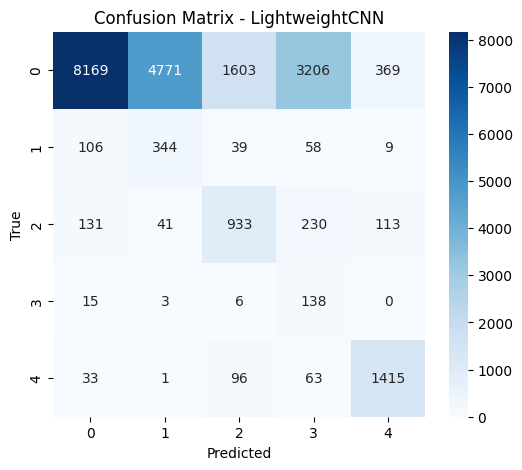

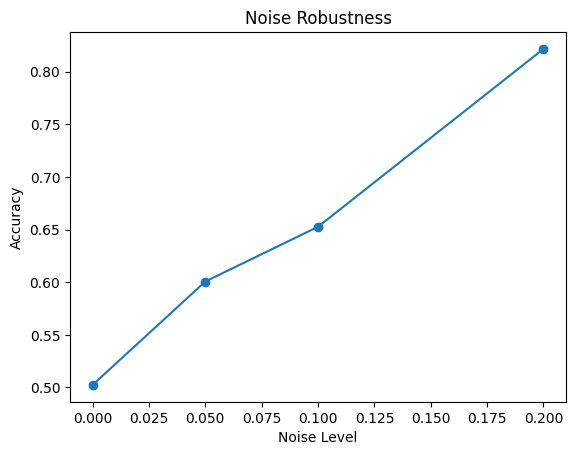

Inference latency: 0.0002806990146636963
            Model  Parameters  Accuracy
0         TinyCNN        3693  0.811895
1  LightweightCNN        1829  0.502421
2            LSTM       50757  0.552119
3        ResNet1D       27845  0.682807


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

X_train = train_df.iloc[:,:-1].values.astype(np.float32)
y_train = train_df.iloc[:,-1].values.astype(np.int64)

X_test = test_df.iloc[:,:-1].values.astype(np.float32)
y_test = test_df.iloc[:,-1].values.astype(np.int64)

X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

print("Train shape:",X_train.shape)
print("Test shape:",X_test.shape)
print("Classes:",np.unique(y_train))

class ECGDataset(Dataset):

    def __init__(self,X,y):

        self.X = torch.tensor(X,dtype=torch.float32)
        self.y = torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):

        x = self.X[idx].unsqueeze(0)
        y = self.y[idx]

        return x,y

train_dataset = ECGDataset(X_train,y_train)
test_dataset = ECGDataset(X_test,y_test)

train_loader = DataLoader(train_dataset,batch_size=128,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=128)

#tinyCNN:
class TinyCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1,8,5)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(8*91,5)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))

        x = x.view(x.size(0),-1)

        x = self.fc(x)

        return x

#LightweightCNN:
class LightweightCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1,16,5)
        self.conv2 = nn.Conv1d(16,32,3)

        self.pool = nn.MaxPool1d(2)

        # adaptive pooling removes size dependency
        self.gap = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(32,5)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        x = self.gap(x)

        x = x.squeeze(-1)

        x = self.fc(x)

        return x

#LSTM Model:
class LSTMModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64,5)

    def forward(self,x):

        x = x.permute(0,2,1)

        out,_ = self.lstm(x)

        out = out[:,-1,:]

        out = self.fc(out)

        return out

#ResNet Model:
class ResidualBlock(nn.Module):

    def __init__(self,in_c,out_c):

        super().__init__()

        self.conv1 = nn.Conv1d(in_c,out_c,3,padding=1)
        self.bn1 = nn.BatchNorm1d(out_c)

        self.conv2 = nn.Conv1d(out_c,out_c,3,padding=1)
        self.bn2 = nn.BatchNorm1d(out_c)

        if in_c != out_c:
            self.shortcut = nn.Conv1d(in_c,out_c,1)
        else:
            self.shortcut = nn.Identity()

    def forward(self,x):

        res = self.shortcut(x)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))

        x += res

        return torch.relu(x)

#Resnet1 Model:
class ResNet1D(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv1d(1,32,7,padding=3)

        self.block1 = ResidualBlock(32,32)
        self.block2 = ResidualBlock(32,64)

        self.pool = nn.AdaptiveAvgPool1d(1)

        self.fc = nn.Linear(64,5)

    def forward(self,x):

        x = torch.relu(self.conv(x))

        x = self.block1(x)
        x = self.block2(x)

        x = self.pool(x)

        x = x.squeeze(-1)

        x = self.fc(x)

        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Weighted Loss:
class_counts = np.bincount(y_train)

weights = 1.0 / class_counts
weights = weights / weights.sum()

weights = torch.tensor(weights,dtype=torch.float32).to(device)

#Training Function:
def train_model(model,epochs=25):

    model = model.to(device)
    class_weights = torch.tensor([1,8,4,10,3]).float().to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.Adam(model.parameters(),lr=0.0005)

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X,y in train_loader:

            X,y = X.to(device),y.to(device)

            optimizer.zero_grad()

            outputs = model(X)

            loss = criterion(outputs,y)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        print("Epoch",epoch+1,"Loss:",total_loss/len(train_loader))

    return model

#Evaluation Function:
def evaluate(model):

    model.eval()

    preds = []
    labels = []

    with torch.no_grad():

        for X,y in test_loader:

            X = X.to(device)

            outputs = model(X)

            pred = torch.argmax(outputs,1).cpu().numpy()

            preds.extend(pred)
            labels.extend(y.numpy())

    acc = accuracy_score(labels,preds)

    print("Accuracy:",acc)

    print("\nClassification Report:")
    print(classification_report(labels,preds))

    return acc,labels,preds

#Training all models:
tiny_model = train_model(TinyCNN(),10)
light_model = train_model(LightweightCNN(),10)
lstm_model = train_model(LSTMModel(),10)
resnet_model = train_model(ResNet1D(),10)

#Evaluating models:
tiny_acc,labels,preds = evaluate(tiny_model)
light_acc,labels2,preds2 = evaluate(light_model)
lstm_acc,_,_ = evaluate(lstm_model)
resnet_acc,_,_ = evaluate(resnet_model)

from sklearn.metrics import f1_score, classification_report

f1 = f1_score(labels, preds, average="macro")
print("Macro F1:", f1)

print(classification_report(labels, preds))

#Confusion Matrix:
cm = confusion_matrix(labels2,preds2)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,cmap="Blues",fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - LightweightCNN")

plt.show()

#Noise Robustness Test:
def add_noise(data,level):

    noise = np.random.normal(0,level,data.shape)

    return data + noise
noise_levels = [0, 0.05, 0.1, 0.2]

for n in noise_levels:

    X_noisy = add_noise(X_test, n)

    preds=[]
    labels=[]

    for X,y in loader:
        X=X.to(device)

        out = tiny_model(X)

        p = torch.argmax(out,1).cpu().numpy()

        preds.extend(p)
        labels.extend(y.numpy())

    acc = accuracy_score(labels,preds)

    print(n,acc)


#Noise plot:
plt.plot(noise_levels,results,marker='o')

plt.xlabel("Noise Level")
plt.ylabel("Accuracy")

plt.title("Noise Robustness")

plt.show()

#latency measurement:
sample = torch.tensor(X_test[:1],dtype=torch.float32).unsqueeze(1).to(device)

start = time.time()

for _ in range(1000):
    light_model(sample)

end = time.time()

latency = (end-start)/1000

print("Inference latency:",latency)

#Comparison table:
data = {

"Model":[
"TinyCNN",
"LightweightCNN",
"LSTM",
"ResNet1D"
],

"Parameters":[
count_params(tiny_model),
count_params(light_model),+
count_params(lstm_model),
count_params(resnet_model)
],

"Accuracy":[
tiny_acc,
light_acc,
lstm_acc,
resnet_acc
]

}

df = pd.DataFrame(data)

print(df)


NEW
 25.3.26 newone cla
# **80:20**

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn ptflops -q

Using device: cpu
Train shape: torch.Size([87554, 1, 187])
Test shape: torch.Size([21892, 1, 187])
Unique labels: tensor([0, 1, 2, 3, 4])

===== Training TinyCNN =====
Epoch 1/25 | Loss: 946.8291
Epoch 2/25 | Loss: 847.7657
Epoch 3/25 | Loss: 840.2387
Epoch 4/25 | Loss: 831.8638
Epoch 5/25 | Loss: 816.6355
Epoch 6/25 | Loss: 769.9158
Epoch 7/25 | Loss: 697.8256
Epoch 8/25 | Loss: 636.1205
Epoch 9/25 | Loss: 593.0824
Epoch 10/25 | Loss: 561.7216
Epoch 11/25 | Loss: 535.7527
Epoch 12/25 | Loss: 514.7456
Epoch 13/25 | Loss: 495.7727
Epoch 14/25 | Loss: 479.4876
Epoch 15/25 | Loss: 465.7468
Epoch 16/25 | Loss: 454.2967
Epoch 17/25 | Loss: 444.4555
Epoch 18/25 | Loss: 435.1100
Epoch 19/25 | Loss: 427.6461
Epoch 20/25 | Loss: 420.5050
Epoch 21/25 | Loss: 414.6838
Epoch 22/25 | Loss: 409.5733
Epoch 23/25 | Loss: 404.1439
Epoch 24/25 | Loss: 399.2861
Epoch 25/25 | Loss: 395.3066

===== Training LightweightCNN =====
Epoch 1/25 | Loss: 880.2314
Epoch 2/25 | Loss: 687.6448
Epoch 3/25 | Loss: 596.

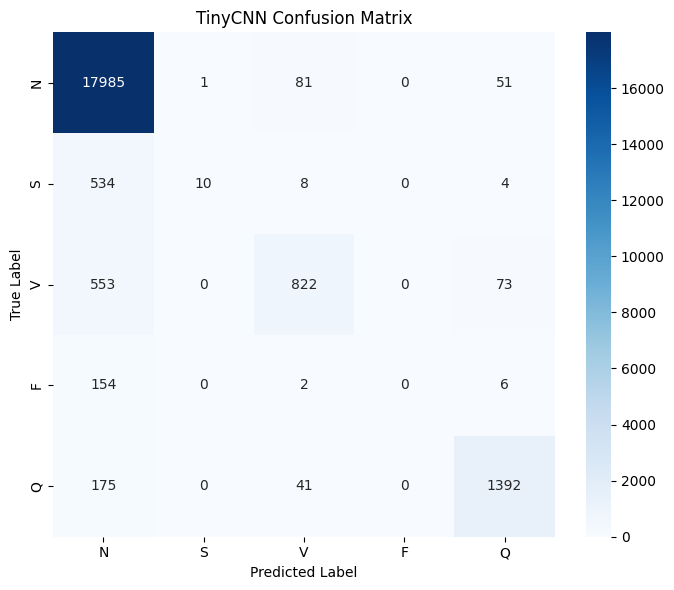

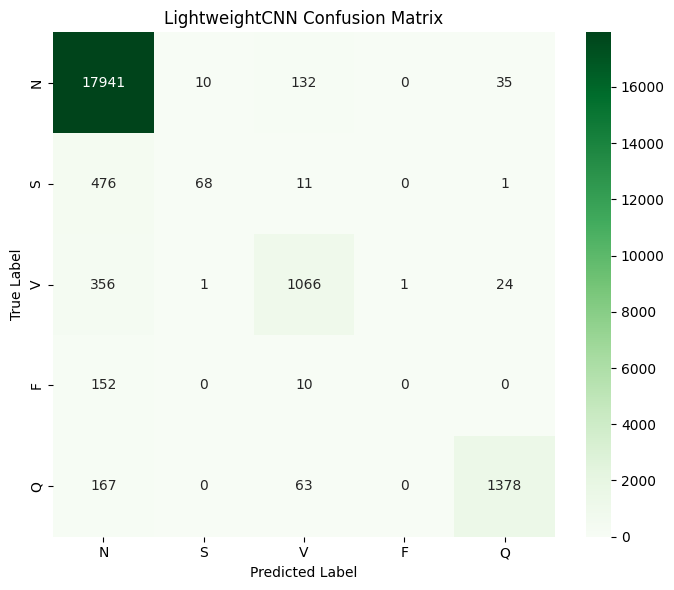

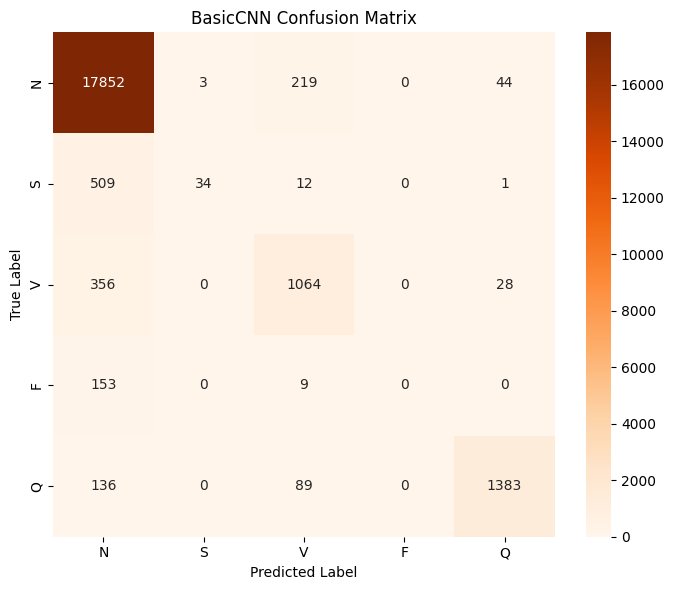

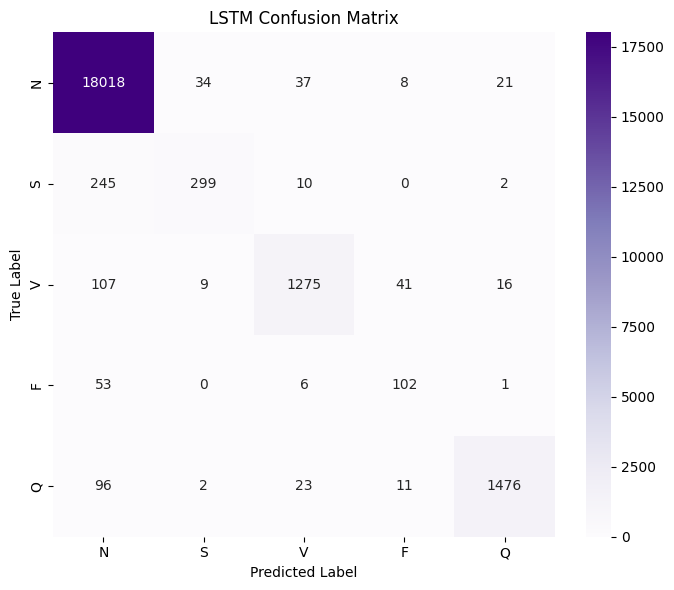

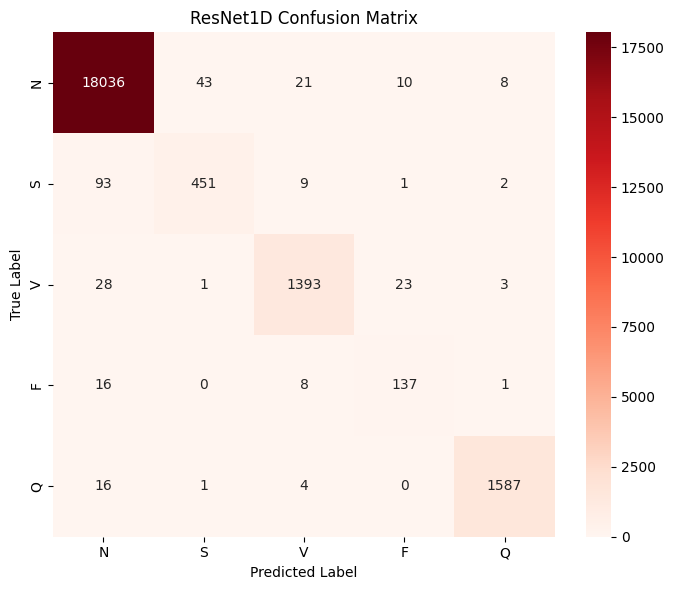


Running Noise Robustness Test...


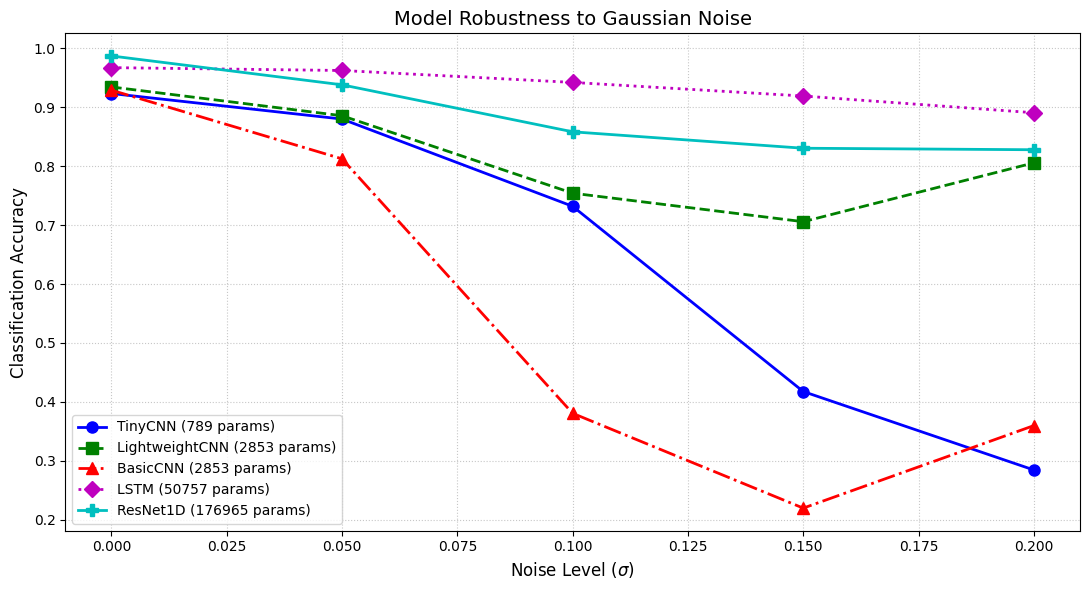

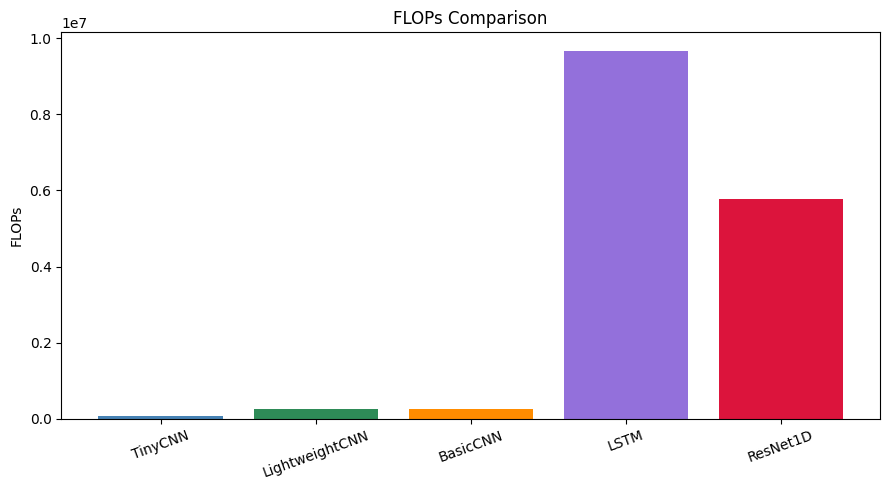

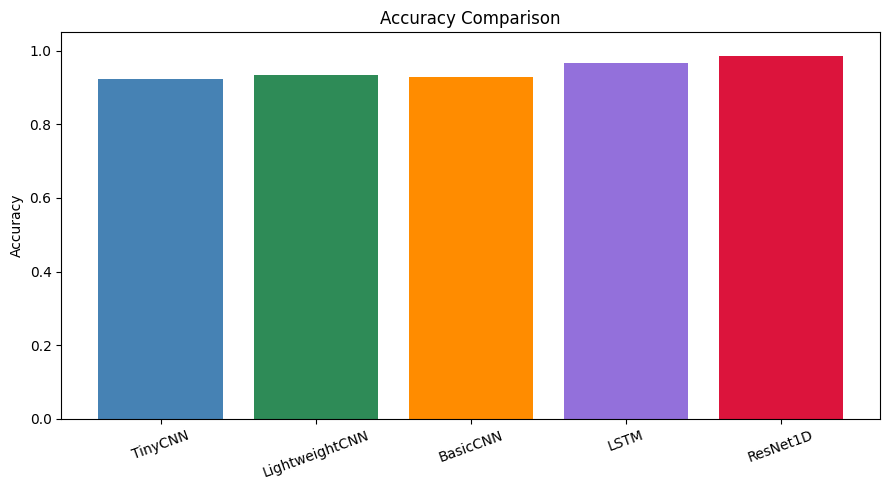

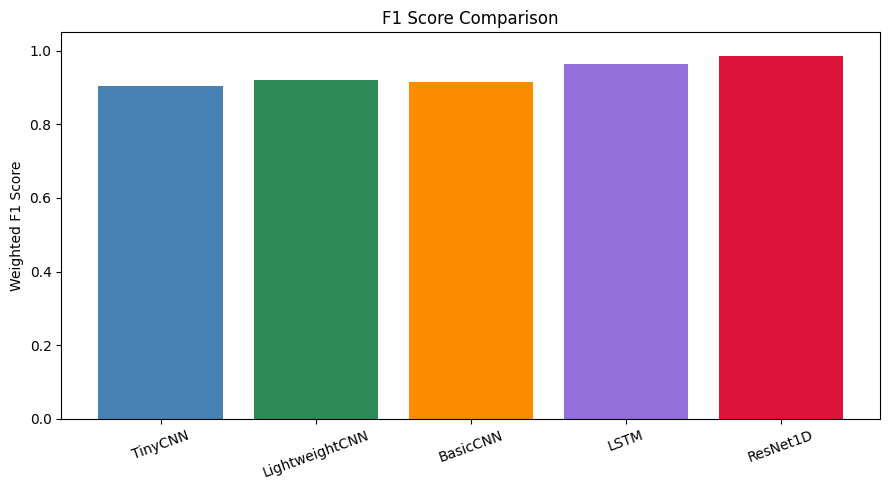

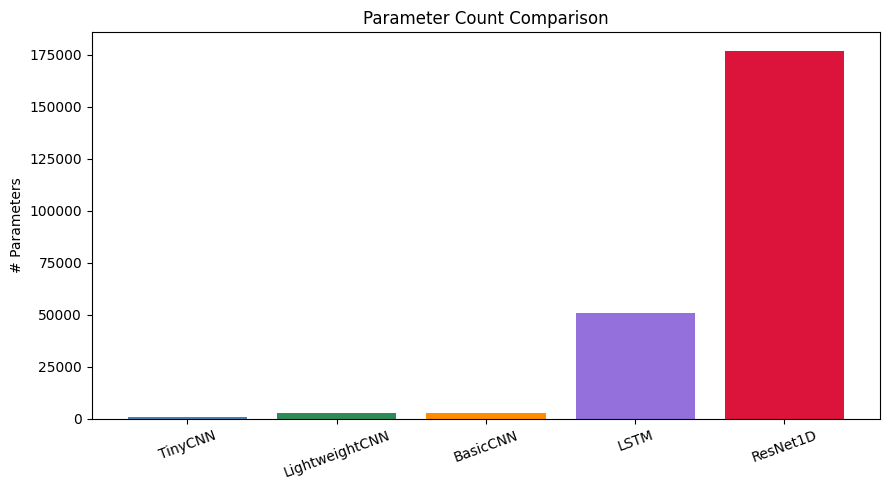

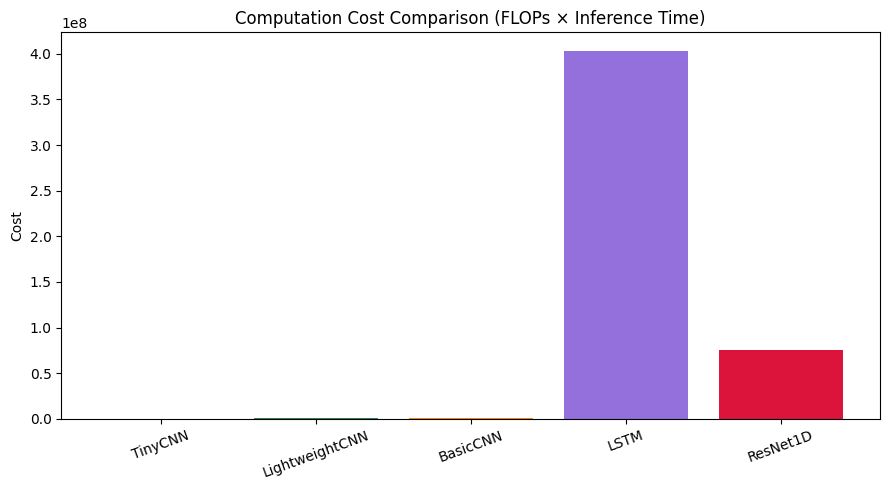

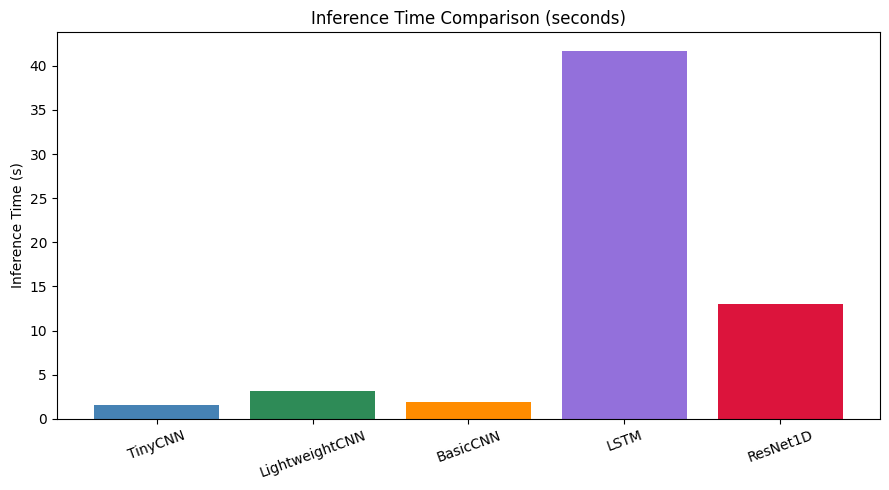

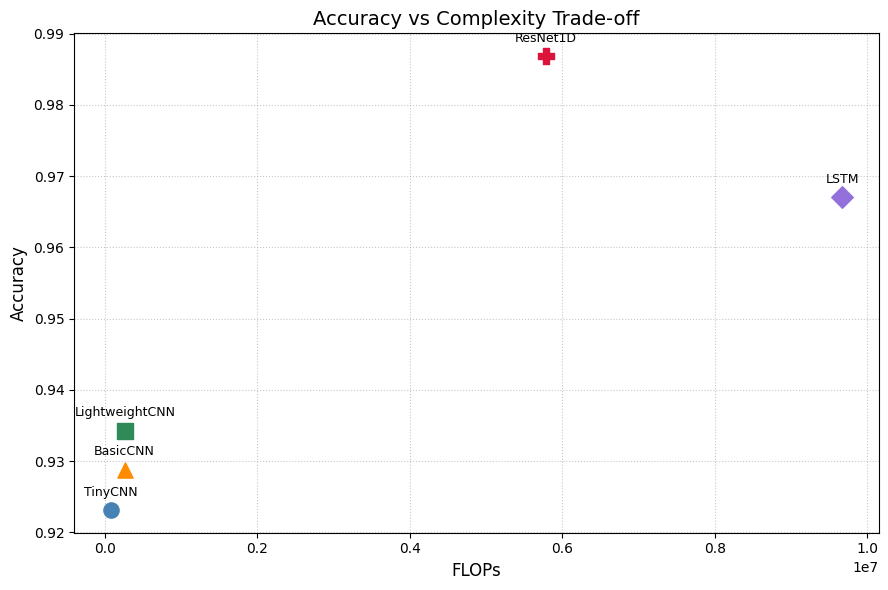

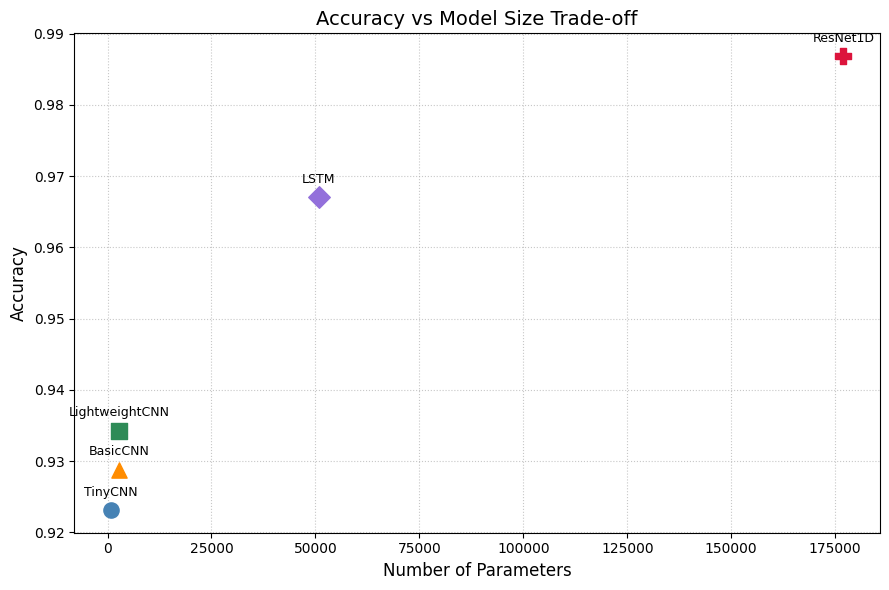


===== Done =====


In [ ]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================
# !pip install torch torchvision scikit-learn matplotlib seaborn ptflops -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from ptflops import get_model_complexity_info


# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD DATASET (SAFE VERSION)
# =========================================================
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df  = pd.read_csv("mitbih_test.csv",  header=None)

# remove any NaN rows
train_df = train_df.dropna()
test_df  = test_df.dropna()

# split features and labels
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# convert labels to integers
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

# convert to tensors  [batch, channels, length]
X_train = torch.tensor(X_train.reshape(-1, 1, 187), dtype=torch.float32)
X_test  = torch.tensor(X_test.reshape(-1,  1, 187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print("Train shape:", X_train.shape)
print("Test shape:",  X_test.shape)
print("Unique labels:", torch.unique(y_train))

# =========================================================
# DATASET CLASS
# =========================================================
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(ECGDataset(X_test,  y_test),  batch_size=64)

# =========================================================
# MODEL 1 : TinyCNN
# =========================================================
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        self.conv1 = nn.Conv1d(1,  8, 5)
        self.conv2 = nn.Conv1d(8, 16, 5)
        self.pool  = nn.MaxPool1d(2)
        self.fc    = nn.Linear(16, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 2 : LightweightCNN
# =========================================================
class LightweightCNN(nn.Module):
    def __init__(self):
        super(LightweightCNN, self).__init__()
        self.conv1 = nn.Conv1d(1,  16, 5)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.pool  = nn.MaxPool1d(2)
        self.fc    = nn.Linear(32, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 3 : BasicCNN
# =========================================================
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,  16, 5)
        self.pool  = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc    = nn.Linear(32, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.gap(x)
        x = x.squeeze(-1)
        return self.fc(x)

# =========================================================
# MODEL 4 : LSTM
# Input shape expected: [batch, channels, length]  →  permute to [batch, length, channels]
# =========================================================
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=5):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [batch, 1, 187]  →  [batch, 187, 1]
        x = x.permute(0, 2, 1)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))   # out: [batch, 187, hidden]
        out = out[:, -1, :]               # last time-step
        return self.fc(out)

# =========================================================
# MODEL 5 : ResNet1D
# =========================================================
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1):
        super(ResidualBlock1D, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1,      padding=padding)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # shortcut to match dimensions when in_channels != out_channels or stride != 1
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNet1D, self).__init__()
        self.entry  = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        self.layer1 = ResidualBlock1D(32,  32)
        self.layer2 = ResidualBlock1D(32,  64, stride=2)
        self.layer3 = ResidualBlock1D(64, 128, stride=2)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        self.fc     = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.entry(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(x)

# =========================================================
# TRAIN FUNCTION
# =========================================================
def train_model(model, epochs=25):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return model

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1, all_labels, all_preds

# =========================================================
# PARAMETER COUNT
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# =========================================================
# FLOPS Computation Function
# =========================================================
def compute_flops(model):
    try:
        with torch.cuda.device(0 if torch.cuda.is_available() else -1):
            macs, _ = get_model_complexity_info(
                model,
                (1, 187),
                as_strings=False,
                print_per_layer_stat=False
            )
        return macs
    except Exception:
        # LSTM is not always supported by ptflops; return 0 as fallback
        return 0

# =========================================================
# INFERENCE TIME
# =========================================================
def measure_inference(model):
    model.eval()
    start = time.time()
    with torch.no_grad():
        model(X_test.to(device))
    end = time.time()
    return end - start

# =========================================================
# COMPUTE COST  (FLOPs × inference time)
# =========================================================
def compute_cost(flops, inf_time):
    return flops * inf_time

# =========================================================
# TRAIN ALL MODELS
# =========================================================
print("\n===== Training TinyCNN =====")
tiny_model  = train_model(TinyCNN(),  epochs=25)

print("\n===== Training LightweightCNN =====")
light_model = train_model(LightweightCNN(), epochs=25)

print("\n===== Training BasicCNN =====")
basic_model = train_model(BasicCNN(), epochs=25)

print("\n===== Training LSTM =====")
lstm_model  = train_model(LSTMClassifier(), epochs=25)

print("\n===== Training ResNet1D =====")
resnet_model = train_model(ResNet1D(), epochs=25)

# =========================================================
# EVALUATE ALL MODELS
# =========================================================
tiny_acc,   tiny_f1,   tiny_labels,   tiny_preds   = evaluate(tiny_model,   test_loader)
light_acc,  light_f1,  light_labels,  light_preds  = evaluate(light_model,  test_loader)
basic_acc,  basic_f1,  basic_labels,  basic_preds  = evaluate(basic_model,  test_loader)
lstm_acc,   lstm_f1,   lstm_labels,   lstm_preds   = evaluate(lstm_model,   test_loader)
resnet_acc, resnet_f1, resnet_labels, resnet_preds = evaluate(resnet_model, test_loader)

print("\n--- Accuracy ---")
print(f"TinyCNN        : {tiny_acc:.4f}   F1: {tiny_f1:.4f}")
print(f"LightweightCNN : {light_acc:.4f}   F1: {light_f1:.4f}")
print(f"BasicCNN       : {basic_acc:.4f}   F1: {basic_f1:.4f}")
print(f"LSTM           : {lstm_acc:.4f}   F1: {lstm_f1:.4f}")
print(f"ResNet1D       : {resnet_acc:.4f}   F1: {resnet_f1:.4f}")

# =========================================================
# BUILD COMPARISON DATAFRAME  (needed for bar/scatter plots)
# =========================================================
model_names  = ["TinyCNN", "LightweightCNN", "BasicCNN", "LSTM", "ResNet1D"]
models_list  = [tiny_model, light_model, basic_model, lstm_model, resnet_model]
accuracies   = [tiny_acc,   light_acc,   basic_acc,   lstm_acc,   resnet_acc]
f1_scores_l  = [tiny_f1,    light_f1,    basic_f1,    lstm_f1,    resnet_f1]

params_list  = [count_parameters(m) for m in models_list]
flops_list   = [compute_flops(m)    for m in models_list]
infer_list   = [measure_inference(m) for m in models_list]
cost_list    = [compute_cost(f, t)  for f, t in zip(flops_list, infer_list)]

df = pd.DataFrame({
    "Model"           : model_names,
    "Accuracy"        : accuracies,
    "F1 Score"        : f1_scores_l,
    "Parameters"      : params_list,
    "FLOPs"           : flops_list,
    "Inference Time"  : infer_list,
    "Computation Cost": cost_list,
})

print("\n--- Comparison Table ---")
print(df.to_string(index=False))

# =========================================================
# AAMI label names
# =========================================================
aami_labels = ['N', 'S', 'V', 'F', 'Q']

# =========================================================
# CONFUSION MATRICES  (one per model)
# =========================================================
def plot_cm(labels, preds, title, cmap="Blues"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=aami_labels, yticklabels=aami_labels)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_cm(tiny_labels,   tiny_preds,   "TinyCNN Confusion Matrix",        cmap="Blues")
plot_cm(light_labels,  light_preds,  "LightweightCNN Confusion Matrix", cmap="Greens")
plot_cm(basic_labels,  basic_preds,  "BasicCNN Confusion Matrix",       cmap="Oranges")
plot_cm(lstm_labels,   lstm_preds,   "LSTM Confusion Matrix",           cmap="Purples")
plot_cm(resnet_labels, resnet_preds, "ResNet1D Confusion Matrix",       cmap="Reds")

# =========================================================
# NOISE ROBUSTNESS TEST
# =========================================================
def add_noise(data, level):
    noise = level * torch.randn_like(data)
    return data + noise

noise_levels  = [0, 0.05, 0.1, 0.15, 0.2]
tiny_results   = []
light_results  = []
basic_results  = []
lstm_results   = []
resnet_results = []

print("\nRunning Noise Robustness Test...")

for nl in noise_levels:
    noisy_X      = add_noise(X_test, nl)
    noisy_loader = DataLoader(ECGDataset(noisy_X, y_test), batch_size=64)

    acc1, _, _, _ = evaluate(tiny_model,   noisy_loader)
    acc2, _, _, _ = evaluate(light_model,  noisy_loader)
    acc3, _, _, _ = evaluate(basic_model,  noisy_loader)
    acc4, _, _, _ = evaluate(lstm_model,   noisy_loader)
    acc5, _, _, _ = evaluate(resnet_model, noisy_loader)

    tiny_results.append(acc1)
    light_results.append(acc2)
    basic_results.append(acc3)
    lstm_results.append(acc4)
    resnet_results.append(acc5)

plt.figure(figsize=(11, 6))
plt.plot(noise_levels, tiny_results,   'b-o',  label=f"TinyCNN ({params_list[0]} params)",        linewidth=2, markersize=8)
plt.plot(noise_levels, light_results,  'g--s', label=f"LightweightCNN ({params_list[1]} params)", linewidth=2, markersize=8)
plt.plot(noise_levels, basic_results,  'r-.^', label=f"BasicCNN ({params_list[2]} params)",       linewidth=2, markersize=8)
plt.plot(noise_levels, lstm_results,   'm:D',  label=f"LSTM ({params_list[3]} params)",            linewidth=2, markersize=8)
plt.plot(noise_levels, resnet_results, 'c-P',  label=f"ResNet1D ({params_list[4]} params)",        linewidth=2, markersize=8)

plt.xlabel("Noise Level ($\\sigma$)", fontsize=12)
plt.ylabel("Classification Accuracy", fontsize=12)
plt.title("Model Robustness to Gaussian Noise", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – FLOPs Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["FLOPs"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("FLOPs Comparison")
plt.ylabel("FLOPs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Accuracy Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Accuracy"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – F1 Score Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["F1 Score"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("F1 Score Comparison")
plt.ylabel("Weighted F1 Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Parameter Count Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Parameters"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Parameter Count Comparison")
plt.ylabel("# Parameters")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Computation Cost Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Computation Cost"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Computation Cost Comparison (FLOPs × Inference Time)")
plt.ylabel("Cost")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Inference Time Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Inference Time"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Inference Time Comparison (seconds)")
plt.ylabel("Inference Time (s)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# SCATTER – Accuracy vs FLOPs  (complexity trade-off)
# =========================================================
colors  = ["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"]
markers = ['o', 's', '^', 'D', 'P']

plt.figure(figsize=(9, 6))
for i in range(len(df)):
    plt.scatter(df["FLOPs"][i], df["Accuracy"][i],
                color=colors[i], marker=markers[i], s=120, zorder=3)
    plt.text(df["FLOPs"][i], df["Accuracy"][i] + 0.002,
             df["Model"][i], fontsize=9, ha='center')

plt.xlabel("FLOPs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Complexity Trade-off", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# SCATTER – Accuracy vs Parameters
# =========================================================
plt.figure(figsize=(9, 6))
for i in range(len(df)):
    plt.scatter(df["Parameters"][i], df["Accuracy"][i],
                color=colors[i], marker=markers[i], s=120, zorder=3)
    plt.text(df["Parameters"][i], df["Accuracy"][i] + 0.002,
             df["Model"][i], fontsize=9, ha='center')

plt.xlabel("Number of Parameters", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Model Size Trade-off", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n===== Done =====")

In [ ]:
df["Efficiency Score"] = df["Accuracy"] / np.log(df["FLOPs"])


In [ ]:
# =========================================================
# EFFICIENCY SCORE (VERY IMPORTANT)
# =========================================================
import numpy as np

# Avoid log(0)
df["Efficiency Score"] = df["Accuracy"] / np.log(df["FLOPs"] + 1)

# Normalize for better comparison (optional but recommended)
df["Efficiency Score (Normalized)"] = (
    df["Efficiency Score"] / df["Efficiency Score"].max()
)

# Sort by efficiency
df_sorted = df.sort_values(by="Efficiency Score (Normalized)", ascending=False)

print("\n===== FINAL ABLATION TABLE =====\n")
print(df_sorted)



===== FINAL ABLATION TABLE =====

            Model  Accuracy  F1 Score  Parameters    FLOPs  Inference Time  \
0         TinyCNN  0.923123  0.904854         789    75197        1.596036   
1  LightweightCNN  0.934268  0.921624        2853   261749        3.111722   
2        BasicCNN  0.928787  0.914715        2853   257413        1.846469   
4        ResNet1D  0.986845  0.986684      176965  5782213       13.012100   
3            LSTM  0.967020  0.965233       50757  9670469       41.706374   

   Computation Cost  Efficiency Score  Efficiency Score (Normalized)  
0      1.200171e+05          0.082217                       1.000000  
1      8.144902e+05          0.074890                       0.910887  
2      4.753051e+05          0.074551                       0.906757  
4      7.523873e+07          0.063380                       0.770886  
3      4.033202e+08          0.060121                       0.731247  


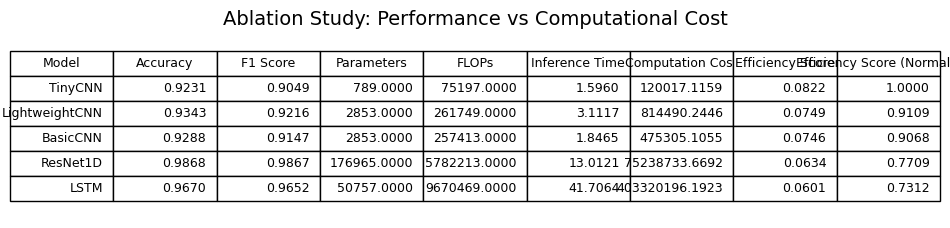

In [ ]:
plt.figure(figsize=(12, (len(df_sorted) + 1) * 0.4)) # Adjust figure size dynamically based on number of rows
plt.axis('off')

# Prepare cellText by rounding only numeric columns and converting all to string
cell_text_data = []
for index, row in df_sorted.iterrows():
    row_data = []
    for col_name, value in row.items():
        # Check if the original column type is numeric before attempting to format as float
        if pd.api.types.is_numeric_dtype(df_sorted[col_name]):
            row_data.append(f"{value:.4f}") # Format numeric to 4 decimal places
        else:
            row_data.append(str(value)) # Convert non-numeric to string
    cell_text_data.append(row_data)

table = plt.table(
    cellText=cell_text_data,
    colLabels=df_sorted.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1,1.5)

plt.title("Ablation Study: Performance vs Computational Cost", fontsize=14)
plt.show()

# **70:30 NOW**

In [ ]:
from sklearn.model_selection import train_test_split

# =========================================================
# LOAD AND CONCATENATE ORIGINAL DATASETS
# =========================================================
# Load both train and test datasets from the original files
original_train_df = pd.read_csv("mitbih_train.csv", header=None)
original_test_df = pd.read_csv("mitbih_test.csv", header=None)

# Combine them into a single dataframe for new splitting
combined_df = pd.concat([original_train_df, original_test_df])
combined_df = combined_df.dropna()

# Split features and labels from the combined dataset
X_combined = combined_df.iloc[:, :-1].values
y_combined = combined_df.iloc[:, -1].values

# Convert labels to integers
y_combined = y_combined.astype(int)

# =========================================================
# PERFORM 70:30 TRAIN-TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

# Convert to tensors, reshaping for CNN input [batch, channels, length]
X_train = torch.tensor(X_train.reshape(-1, 1, 187), dtype=torch.float32)
X_test = torch.tensor(X_test.reshape(-1, 1, 187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("New Train shape (70%):", X_train.shape)
print("New Test shape (30%):", X_test.shape)
print("Unique labels in new training set:", torch.unique(y_train))
print("Unique labels in new test set:", torch.unique(y_test))

# =========================================================
# RECREATE DATALOADERS WITH NEW SPLIT
# =========================================================
train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=64, shuffle=False)

print("\nData re-split to 70:30 and new DataLoaders created successfully.")

New Train shape (70%): torch.Size([76612, 1, 187])
New Test shape (30%): torch.Size([32834, 1, 187])
Unique labels in new training set: tensor([0, 1, 2, 3, 4])
Unique labels in new test set: tensor([0, 1, 2, 3, 4])

Data re-split to 70:30 and new DataLoaders created successfully.


Using device: cpu
New Train shape (70%): torch.Size([76612, 1, 187])
New Test shape (30%): torch.Size([32834, 1, 187])
Unique labels in new training set: tensor([0, 1, 2, 3, 4])
Unique labels in new test set: tensor([0, 1, 2, 3, 4])

Data re-split to 70:30 and new DataLoaders created successfully.

===== Training TinyCNN =====
Epoch 1/25 | Loss: 807.9575
Epoch 2/25 | Loss: 707.0131
Epoch 3/25 | Loss: 624.1495
Epoch 4/25 | Loss: 554.9495
Epoch 5/25 | Loss: 528.3157
Epoch 6/25 | Loss: 511.8123
Epoch 7/25 | Loss: 494.5107
Epoch 8/25 | Loss: 473.5919
Epoch 9/25 | Loss: 454.2975
Epoch 10/25 | Loss: 438.7044
Epoch 11/25 | Loss: 426.7132
Epoch 12/25 | Loss: 417.7100
Epoch 13/25 | Loss: 410.6838
Epoch 14/25 | Loss: 404.6201
Epoch 15/25 | Loss: 398.4947
Epoch 16/25 | Loss: 394.0210
Epoch 17/25 | Loss: 389.0569
Epoch 18/25 | Loss: 384.6069
Epoch 19/25 | Loss: 380.7410
Epoch 20/25 | Loss: 376.8460
Epoch 21/25 | Loss: 372.3346
Epoch 22/25 | Loss: 368.4870
Epoch 23/25 | Loss: 365.3950
Epoch 24/25 |

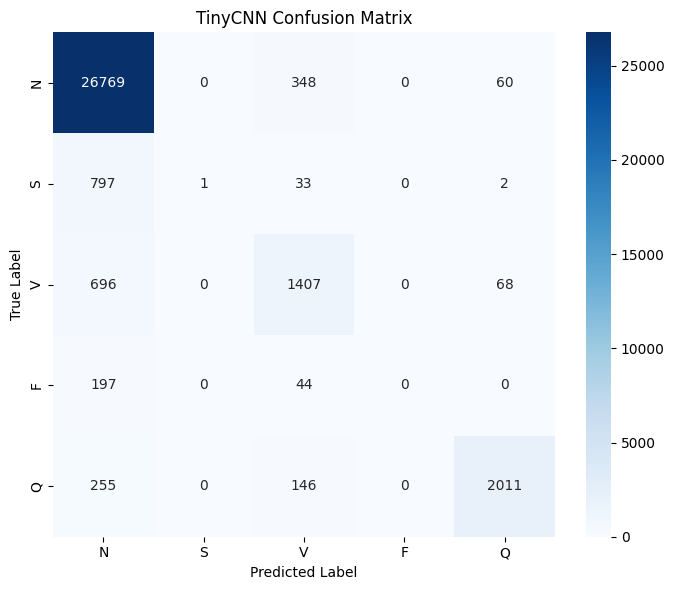

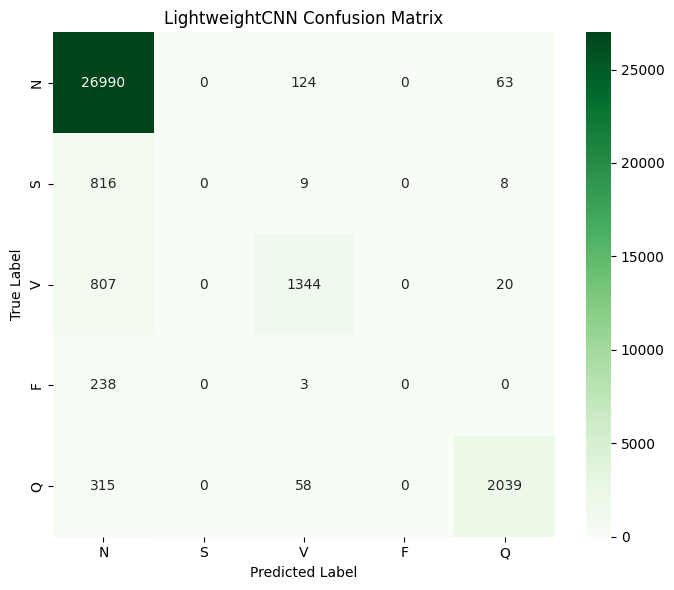

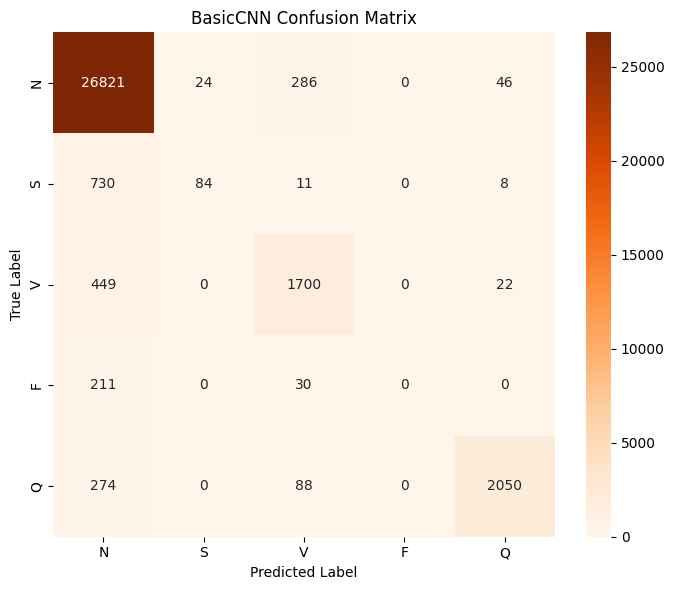

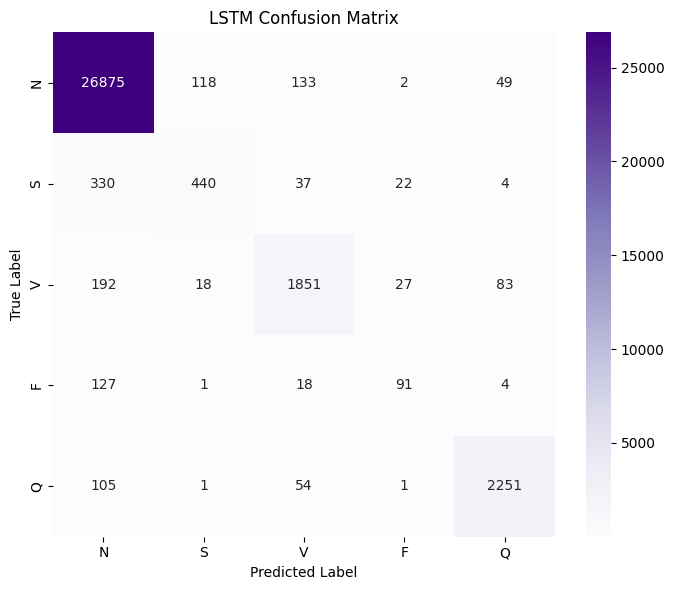

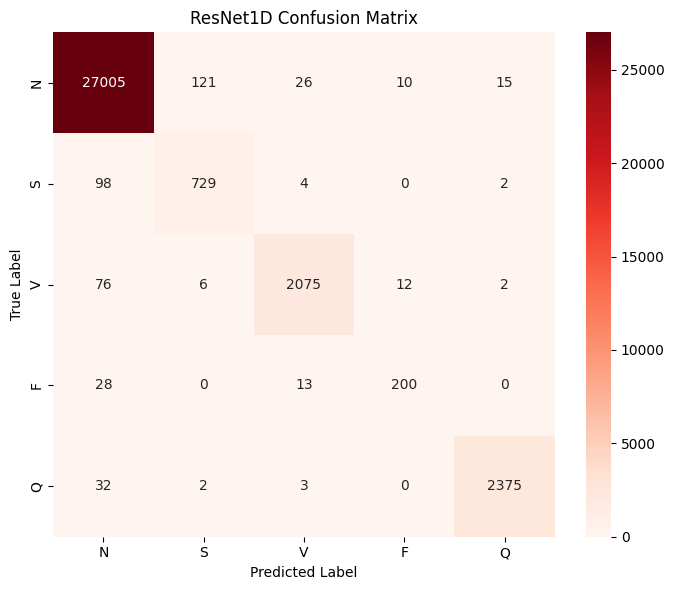


Running Noise Robustness Test...


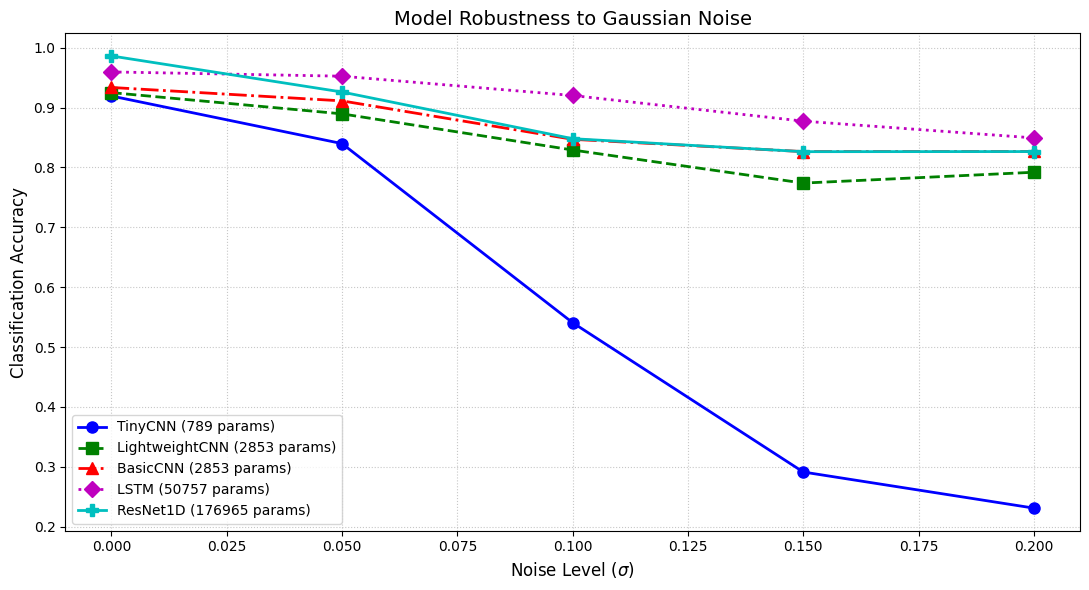

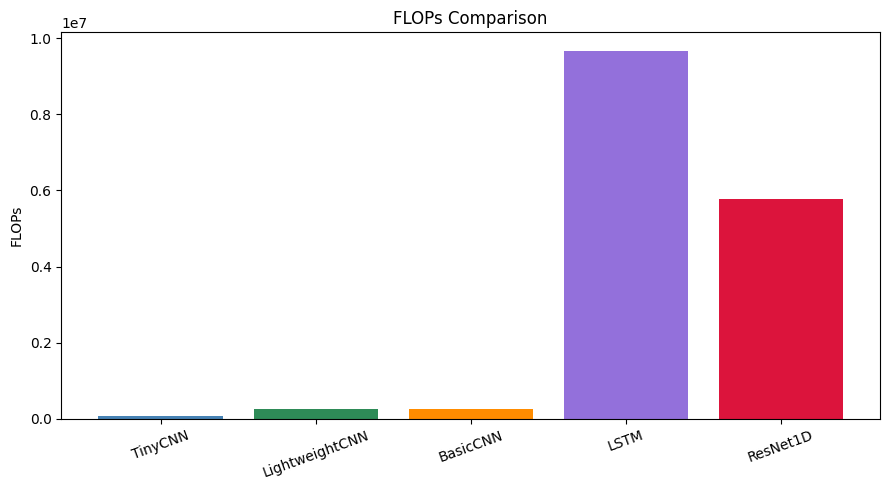

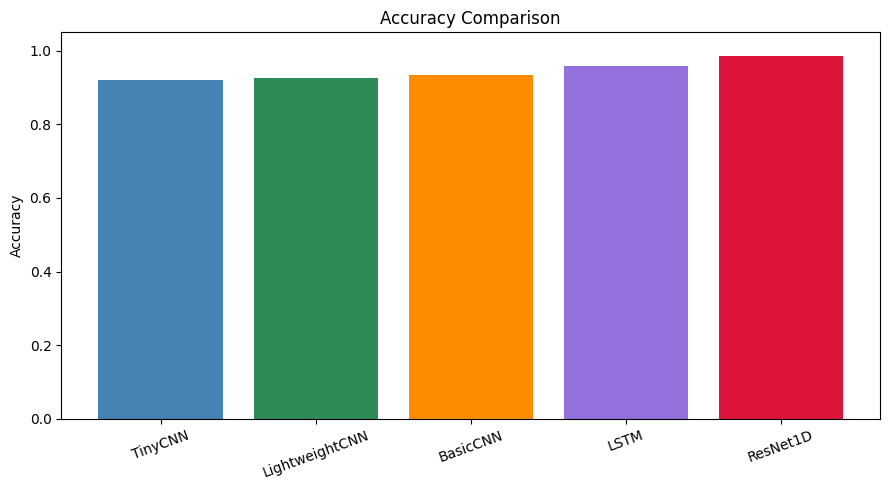

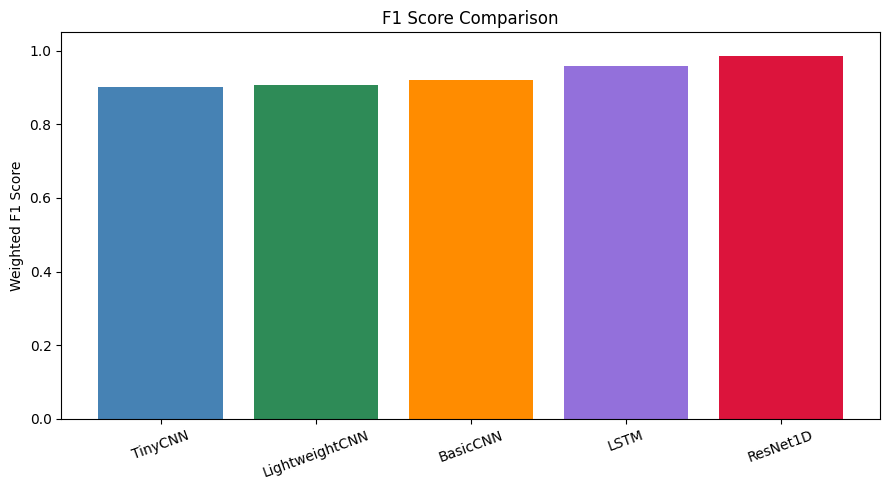

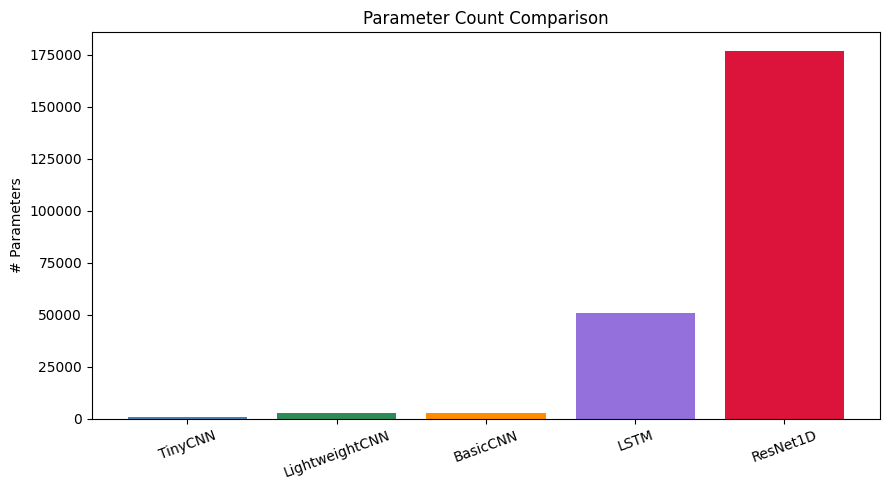

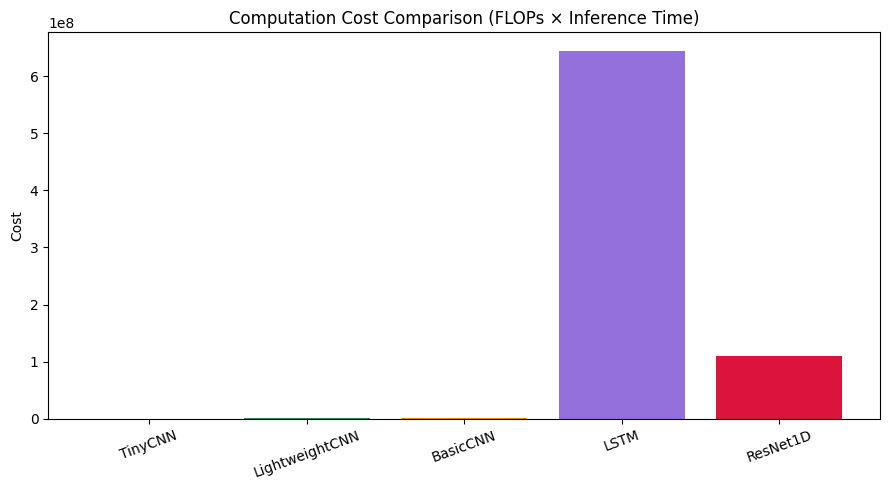

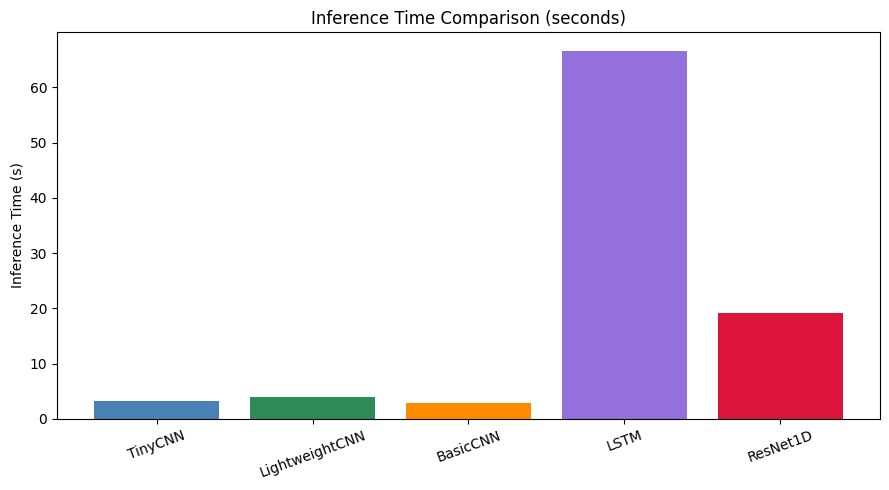

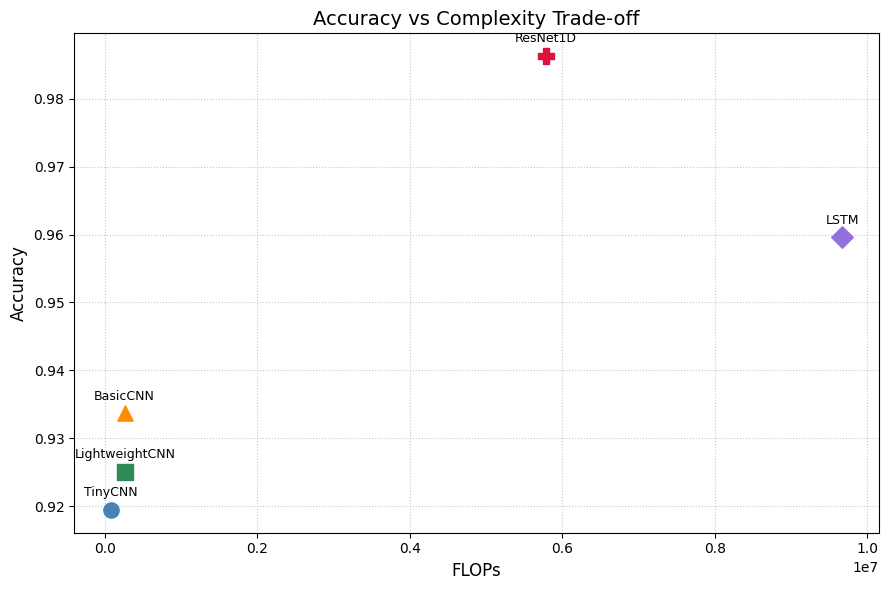

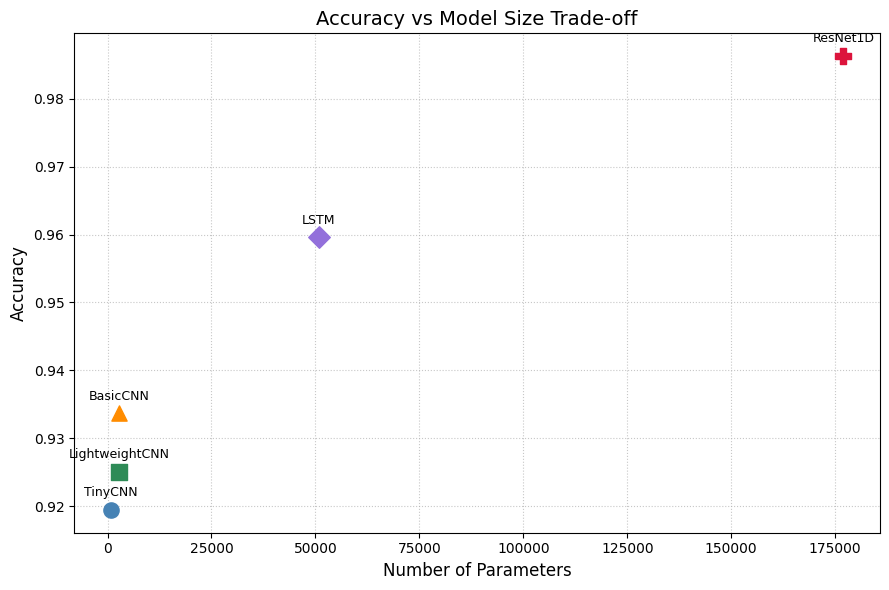


===== Done =====


In [ ]:
# =========================================================
# INSTALL LIBRARIES
# =========================================================
# !pip install torch torchvision scikit-learn matplotlib seaborn ptflops -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from ptflops import get_model_complexity_info


# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================================================
# LOAD DATASET (SAFE VERSION)
# =========================================================
from sklearn.model_selection import train_test_split

# =========================================================
# LOAD AND CONCATENATE ORIGINAL DATASETS
# =========================================================
# Load both train and test datasets from the original files
original_train_df = pd.read_csv("mitbih_train.csv", header=None)
original_test_df = pd.read_csv("mitbih_test.csv", header=None)

# Combine them into a single dataframe for new splitting
combined_df = pd.concat([original_train_df, original_test_df])
combined_df = combined_df.dropna()

# Split features and labels from the combined dataset
X_combined = combined_df.iloc[:, :-1].values
y_combined = combined_df.iloc[:, -1].values

# Convert labels to integers
y_combined = y_combined.astype(int)

# =========================================================
# PERFORM 70:30 TRAIN-TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, test_size=0.3, random_state=42, stratify=y_combined
)

# Convert to tensors, reshaping for CNN input [batch, channels, length]
X_train = torch.tensor(X_train.reshape(-1, 1, 187), dtype=torch.float32)
X_test = torch.tensor(X_test.reshape(-1, 1, 187), dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("New Train shape (70%):", X_train.shape)
print("New Test shape (30%):", X_test.shape)
print("Unique labels in new training set:", torch.unique(y_train))
print("Unique labels in new test set:", torch.unique(y_test))

# =========================================================
# RECREATE DATALOADERS WITH NEW SPLIT
# =========================================================
train_loader = DataLoader(ECGDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(ECGDataset(X_test, y_test), batch_size=64, shuffle=False)

print("\nData re-split to 70:30 and new DataLoaders created successfully.")

# =========================================================
# MODEL 1 : TinyCNN
# =========================================================
class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()
        self.conv1 = nn.Conv1d(1,  8, 5)
        self.conv2 = nn.Conv1d(8, 16, 5)
        self.pool  = nn.MaxPool1d(2)
        self.fc    = nn.Linear(16, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 2 : LightweightCNN
# =========================================================
class LightweightCNN(nn.Module):
    def __init__(self):
        super(LightweightCNN, self).__init__()
        self.conv1 = nn.Conv1d(1,  16, 5)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.pool  = nn.MaxPool1d(2)
        self.fc    = nn.Linear(32, 5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.adaptive_avg_pool1d(x, 1).squeeze(-1)
        x = self.fc(x)
        return x

# =========================================================
# MODEL 3 : BasicCNN
# =========================================================
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,  16, 5)
        self.pool  = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(16, 32, 5)
        self.gap   = nn.AdaptiveAvgPool1d(1)
        self.fc    = nn.Linear(32, 5)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.gap(x)
        x = x.squeeze(-1)
        return self.fc(x)

# =========================================================
# MODEL 4 : LSTM
# Input shape expected: [batch, channels, length]  →  permute to [batch, length, channels]
# =========================================================
class LSTMClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, num_classes=5):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: [batch, 1, 187]  →  [batch, 187, 1]
        x = x.permute(0, 2, 1)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))   # out: [batch, 187, hidden]
        out = out[:, -1, :]               # last time-step
        return self.fc(out)

# =========================================================
# MODEL 5 : ResNet1D
# =========================================================
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1):
        super(ResidualBlock1D, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv1d(in_channels,  out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1   = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1,      padding=padding)
        self.bn2   = nn.BatchNorm1d(out_channels)

        # shortcut to match dimensions when in_channels != out_channels or stride != 1
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet1D(nn.Module):
    def __init__(self, num_classes=5):
        super(ResNet1D, self).__init__()
        self.entry  = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        self.layer1 = ResidualBlock1D(32,  32)
        self.layer2 = ResidualBlock1D(32,  64, stride=2)
        self.layer3 = ResidualBlock1D(64, 128, stride=2)
        self.gap    = nn.AdaptiveAvgPool1d(1)
        self.fc     = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.entry(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x).squeeze(-1)
        return self.fc(x)

# =========================================================
# TRAIN FUNCTION
# =========================================================
def train_model(model, epochs=25):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

    return model

# =========================================================
# EVALUATION FUNCTION
# =========================================================
def evaluate(model, loader):
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs  = inputs.to(device)
            outputs = model(inputs)
            preds   = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1, all_labels, all_preds

# =========================================================
# PARAMETER COUNT
# =========================================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# =========================================================
# FLOPS Computation Function
# =========================================================
def compute_flops(model):
    try:
        with torch.cuda.device(0 if torch.cuda.is_available() else -1):
            macs, _ = get_model_complexity_info(
                model,
                (1, 187),
                as_strings=False,
                print_per_layer_stat=False
            )
        return macs
    except Exception:
        # LSTM is not always supported by ptflops; return 0 as fallback
        return 0

# =========================================================
# INFERENCE TIME
# =========================================================
def measure_inference(model):
    model.eval()
    start = time.time()
    with torch.no_grad():
        model(X_test.to(device))
    end = time.time()
    return end - start

# =========================================================
# COMPUTE COST  (FLOPs × inference time)
# =========================================================
def compute_cost(flops, inf_time):
    return flops * inf_time

# =========================================================
# TRAIN ALL MODELS
# =========================================================
print("\n===== Training TinyCNN =====")
tiny_model  = train_model(TinyCNN(),  epochs=25)

print("\n===== Training LightweightCNN =====")
light_model = train_model(LightweightCNN(), epochs=25)

print("\n===== Training BasicCNN =====")
basic_model = train_model(BasicCNN(), epochs=25)

print("\n===== Training LSTM =====")
lstm_model  = train_model(LSTMClassifier(), epochs=25)

print("\n===== Training ResNet1D =====")
resnet_model = train_model(ResNet1D(), epochs=25)

# =========================================================
# EVALUATE ALL MODELS
# =========================================================
tiny_acc,   tiny_f1,   tiny_labels,   tiny_preds   = evaluate(tiny_model,   test_loader)
light_acc,  light_f1,  light_labels,  light_preds  = evaluate(light_model,  test_loader)
basic_acc,  basic_f1,  basic_labels,  basic_preds  = evaluate(basic_model,  test_loader)
lstm_acc,   lstm_f1,   lstm_labels,   lstm_preds   = evaluate(lstm_model,   test_loader)
resnet_acc, resnet_f1, resnet_labels, resnet_preds = evaluate(resnet_model, test_loader)

print("\n--- Accuracy ---")
print(f"TinyCNN        : {tiny_acc:.4f}   F1: {tiny_f1:.4f}")
print(f"LightweightCNN : {light_acc:.4f}   F1: {light_f1:.4f}")
print(f"BasicCNN       : {basic_acc:.4f}   F1: {basic_f1:.4f}")
print(f"LSTM           : {lstm_acc:.4f}   F1: {lstm_f1:.4f}")
print(f"ResNet1D       : {resnet_acc:.4f}   F1: {resnet_f1:.4f}")

# =========================================================
# BUILD COMPARISON DATAFRAME  (needed for bar/scatter plots)
# =========================================================
model_names  = ["TinyCNN", "LightweightCNN", "BasicCNN", "LSTM", "ResNet1D"]
models_list  = [tiny_model, light_model, basic_model, lstm_model, resnet_model]
accuracies   = [tiny_acc,   light_acc,   basic_acc,   lstm_acc,   resnet_acc]
f1_scores_l  = [tiny_f1,    light_f1,    basic_f1,    lstm_f1,    resnet_f1]

params_list  = [count_parameters(m) for m in models_list]
flops_list   = [compute_flops(m)    for m in models_list]
infer_list   = [measure_inference(m) for m in models_list]
cost_list    = [compute_cost(f, t)  for f, t in zip(flops_list, infer_list)]

df = pd.DataFrame({
    "Model"           : model_names,
    "Accuracy"        : accuracies,
    "F1 Score"        : f1_scores_l,
    "Parameters"      : params_list,
    "FLOPs"           : flops_list,
    "Inference Time"  : infer_list,
    "Computation Cost": cost_list,
})

print("\n--- Comparison Table ---")
print(df.to_string(index=False))

# =========================================================
# EFFICIENCY SCORE (VERY IMPORTANT)
# =========================================================
# Avoid log(0)
df["Efficiency Score"] = df["Accuracy"] / np.log(df["FLOPs"] + 1)

# Normalize for better comparison (optional but recommended)
df["Efficiency Score (Normalized)"] = (
    df["Efficiency Score"] / df["Efficiency Score"].max()
)

# Sort by efficiency
df_sorted = df.sort_values(by="Efficiency Score (Normalized)", ascending=False)

print("\n===== FINAL ABLATION TABLE =====\n")
print(df_sorted.to_string(index=False))

# =========================================================
# AAMI label names
# =========================================================
aami_labels = ['N', 'S', 'V', 'F', 'Q']

# =========================================================
# CONFUSION MATRICES  (one per model)
# =========================================================
def plot_cm(labels, preds, title, cmap="Blues"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=aami_labels, yticklabels=aami_labels)
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

plot_cm(tiny_labels,   tiny_preds,   "TinyCNN Confusion Matrix",        cmap="Blues")
plot_cm(light_labels,  light_preds,  "LightweightCNN Confusion Matrix", cmap="Greens")
plot_cm(basic_labels,  basic_preds,  "BasicCNN Confusion Matrix",       cmap="Oranges")
plot_cm(lstm_labels,   lstm_preds,   "LSTM Confusion Matrix",           cmap="Purples")
plot_cm(resnet_labels, resnet_preds, "ResNet1D Confusion Matrix",       cmap="Reds")

# =========================================================
# NOISE ROBUSTNESS TEST
# =========================================================
def add_noise(data, level):
    noise = level * torch.randn_like(data)
    return data + noise

noise_levels  = [0, 0.05, 0.1, 0.15, 0.2]
tiny_results   = []
light_results  = []
basic_results  = []
lstm_results   = []
resnet_results = []

print("\nRunning Noise Robustness Test...")

for nl in noise_levels:
    noisy_X      = add_noise(X_test, nl)
    noisy_loader = DataLoader(ECGDataset(noisy_X, y_test), batch_size=64)

    acc1, _, _, _ = evaluate(tiny_model,   noisy_loader)
    acc2, _, _, _ = evaluate(light_model,  noisy_loader)
    acc3, _, _, _ = evaluate(basic_model,  noisy_loader)
    acc4, _, _, _ = evaluate(lstm_model,   noisy_loader)
    acc5, _, _, _ = evaluate(resnet_model, noisy_loader)

    tiny_results.append(acc1)
    light_results.append(acc2)
basic_results.append(acc3)
lstm_results.append(acc4)
resnet_results.append(acc5)

plt.figure(figsize=(11, 6))
plt.plot(noise_levels, tiny_results,   'b-o',  label=f"TinyCNN ({params_list[0]} params)",        linewidth=2, markersize=8)
plt.plot(noise_levels, light_results,  'g--s', label=f"LightweightCNN ({params_list[1]} params)", linewidth=2, markersize=8)
plt.plot(noise_levels, basic_results,  'r-.^', label=f"BasicCNN ({params_list[2]} params)",       linewidth=2, markersize=8)
plt.plot(noise_levels, lstm_results,   'm:D',  label=f"LSTM ({params_list[3]} params)",            linewidth=2, markersize=8)
plt.plot(noise_levels, resnet_results, 'c-P',  label=f"ResNet1D ({params_list[4]} params)",        linewidth=2, markersize=8)

plt.xlabel("Noise Level (\\$\sigma\\$)", fontsize=12)
plt.ylabel("Classification Accuracy", fontsize=12)
plt.title("Model Robustness to Gaussian Noise", fontsize=14)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – FLOPs Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["FLOPs"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("FLOPs Comparison")
plt.ylabel("FLOPs")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Accuracy Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Accuracy"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – F1 Score Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["F1 Score"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("F1 Score Comparison")
plt.ylabel("Weighted F1 Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Parameter Count Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Parameters"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Parameter Count Comparison")
plt.ylabel("# Parameters")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Computation Cost Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Computation Cost"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Computation Cost Comparison (FLOPs \\u00d7 Inference Time)")
plt.ylabel("Cost")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# BAR – Inference Time Comparison
# =========================================================
plt.figure(figsize=(9, 5))
plt.bar(df["Model"], df["Inference Time"], color=["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"])
plt.title("Inference Time Comparison (seconds)")
plt.ylabel("Inference Time (s)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# =========================================================
# SCATTER – Accuracy vs FLOPs  (complexity trade-off)
# =========================================================
colors  = ["steelblue", "seagreen", "darkorange", "mediumpurple", "crimson"]
markers = ['o', 's', '^', 'D', 'P']

plt.figure(figsize=(9, 6))
for i in range(len(df)):
    plt.scatter(df["FLOPs"][i], df["Accuracy"][i],
                color=colors[i], marker=markers[i], s=120, zorder=3)
    plt.text(df["FLOPs"][i], df["Accuracy"][i] + 0.002,
             df["Model"][i], fontsize=9, ha='center')

plt.xlabel("FLOPs", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Complexity Trade-off", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================================================
# SCATTER – Accuracy vs Parameters
# =========================================================
plt.figure(figsize=(9, 6))
for i in range(len(df)):
    plt.scatter(df["Parameters"][i], df["Accuracy"][i],
                color=colors[i], marker=markers[i], s=120, zorder=3)
    plt.text(df["Parameters"][i], df["Accuracy"][i] + 0.002,
             df["Model"][i], fontsize=9, ha='center')

plt.xlabel("Number of Parameters", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Accuracy vs Model Size Trade-off", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n===== Done ====")

NEW 13.4 Final Version 


Train: (74738, 187) Test: (21892, 187)
Epoch 1 Loss: 0.5251
Epoch 2 Loss: 0.3621
Epoch 3 Loss: 0.3368
Epoch 4 Loss: 0.3245
Epoch 5 Loss: 0.3165
Epoch 6 Loss: 0.3085
Epoch 7 Loss: 0.3012
Epoch 8 Loss: 0.2976
Epoch 9 Loss: 0.2932
Epoch 10 Loss: 0.2888
Epoch 11 Loss: 0.2859
Epoch 12 Loss: 0.2828
Epoch 13 Loss: 0.2805
Epoch 14 Loss: 0.2778
Epoch 15 Loss: 0.2771
Epoch 16 Loss: 0.2746
Epoch 17 Loss: 0.2733
Epoch 18 Loss: 0.2710
Epoch 19 Loss: 0.2703
Epoch 20 Loss: 0.2689
Epoch 21 Loss: 0.2668
Epoch 22 Loss: 0.2657
Epoch 23 Loss: 0.2648
Epoch 24 Loss: 0.2637
Epoch 25 Loss: 0.2617
Epoch 1 Loss: 0.7109
Epoch 2 Loss: 0.5026
Epoch 3 Loss: 0.4850
Epoch 4 Loss: 0.4771
Epoch 5 Loss: 0.4738
Epoch 6 Loss: 0.4719
Epoch 7 Loss: 0.4699
Epoch 8 Loss: 0.4695
Epoch 9 Loss: 0.4690
Epoch 10 Loss: 0.4695
Epoch 11 Loss: 0.4672
Epoch 12 Loss: 0.4681
Epoch 13 Loss: 0.4673
Epoch 14 Loss: 0.4671
Epoch 15 Loss: 0.4668
Epoch 16 Loss: 0.4655
Epoch 17 Loss: 0.4651
Epoch 18 Loss: 0.4642
Epoch 19 Loss: 0.4643
Epoch 20 Lo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.8200712589073634
F1: 0.2024062482538878
              precision    recall  f1-score   support

           0       0.83      0.99      0.90     18118
           1       0.17      0.08      0.11       556
           2       0.00      0.00      0.00      1448
           3       0.00      0.00      0.00       162
           4       0.00      0.00      0.00      1608

    accuracy                           0.82     21892
   macro avg       0.20      0.21      0.20     21892
weighted avg       0.69      0.82      0.75     21892



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


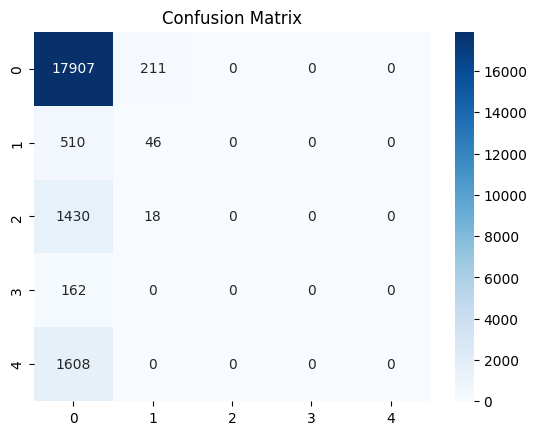

Gaussian 0.8271514708569341
Baseline 0.8163712771788781
Motion 0.8276082587246483


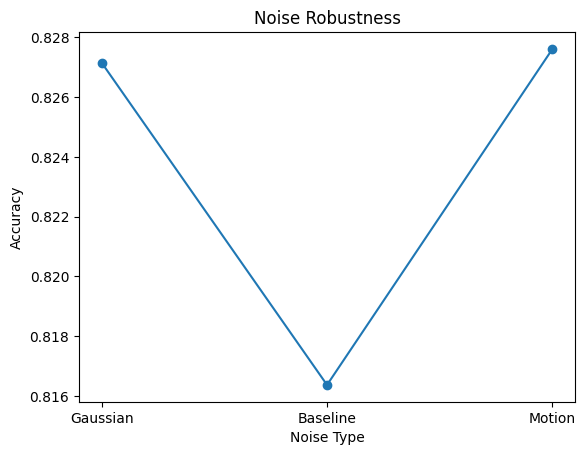

Latency: 0.0003886594772338867
         Model  Params  Accuracy        F1
0   TinyCNN+SE    3735  0.828202  0.281103
1  LightCNN+SE    2529  0.820071  0.202406


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from torch.utils.data import Dataset, DataLoader

# =========================
# LOAD DATA
# =========================
pd.set_option('display.max_columns', None)
train_df = pd.read_csv("mitbih_train.csv", header=None, low_memory=False)
test_df = pd.read_csv("mitbih_test.csv", header=None, low_memory=False)

# Apply pd.to_numeric to all columns, coercing errors, then drop NaNs
train_df = train_df.apply(pd.to_numeric, errors='coerce')
train_df = train_df.dropna()

test_df = test_df.apply(pd.to_numeric, errors='coerce')
test_df = test_df.dropna()

# Split features and labels
X_train = np.nan_to_num(train_df.iloc[:, :-1].values).astype(np.float32)
y_train = train_df.iloc[:, -1].values.astype(np.int64)

X_test = np.nan_to_num(test_df.iloc[:, :-1].values).astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(np.int64)

print("Train:", X_train.shape, "Test:", X_test.shape)

# =========================
# DATASET
# =========================
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx].unsqueeze(0), self.y[idx]

train_loader = DataLoader(ECGDataset(X_train,y_train), batch_size=128, shuffle=True)
test_loader = DataLoader(ECGDataset(X_test,y_test), batch_size=128)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# SE ATTENTION BLOCK (NOVELTY)
# =========================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)

    def forward(self, x):
        b, c, l = x.size()
        y = x.mean(dim=2)
        y = torch.relu(self.fc1(y))
        y = torch.sigmoid(self.fc2(y))
        y = y.view(b, c, 1)
        return x * y

# =========================
# MODELS
# =========================
class TinyCNN_SE(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 8, 5)
        self.se1 = SEBlock(8)
        self.pool = nn.MaxPool1d(2)
        self.fc = nn.Linear(8*91, 5)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.se1(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class LightweightCNN_SE(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, 5)
        self.se1 = SEBlock(16)

        self.conv2 = nn.Conv1d(16, 32, 3)
        self.se2 = SEBlock(32)

        self.pool = nn.MaxPool1d(2)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, 5)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.se1(x)
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.se2(x)
        x = self.pool(x)

        x = self.gap(x).squeeze(-1)
        return self.fc(x)

# =========================
# TRAIN FUNCTION
# =========================
def train_model(model, epochs=25):
    model.to(device)
    weights = torch.tensor([1,8,4,10,3], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    return model

# =========================
# EVALUATE
# =========================
def evaluate(model):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X, y in test_loader:
            X = X.to(device)
            out = model(X)
            p = torch.argmax(out,1).cpu().numpy()

            preds.extend(p)
            labels.extend(y.numpy())

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")

    print("Accuracy:", acc)
    print("F1:", f1)
    print(classification_report(labels, preds))

    return acc, f1, labels, preds

# =========================
# TRAIN
# =========================
tiny_model = train_model(TinyCNN_SE())
light_model = train_model(LightweightCNN_SE())

# =========================
# TEST
# =========================
tiny_acc, tiny_f1, _, _ = evaluate(tiny_model)
light_acc, light_f1, labels, preds = evaluate(light_model)

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================
# NOISE FUNCTIONS
# =========================
def add_gaussian(data):
    return data + np.random.normal(0, 0.1, data.shape)

def add_baseline(data):
    t = np.linspace(0,1,data.shape[1])
    wander = 0.1*np.sin(2*np.pi*0.5*t)
    return data + wander

def add_motion(data):
    return data + np.random.normal(0, 0.2, data.shape)

# =========================
# NOISE TEST
# =========================
noise_types = {
    "Gaussian": add_gaussian,
    "Baseline": add_baseline,
    "Motion": add_motion
}

results = {}

for name, func in noise_types.items():
    X_noisy = func(X_test)

    loader = DataLoader(ECGDataset(X_noisy, y_test), batch_size=128)

    preds, labels = [], []

    for X, y in loader:
        X = X.to(device)
        out = light_model(X)
        p = torch.argmax(out,1).cpu().numpy()

        preds.extend(p)
        labels.extend(y.numpy())

    acc = accuracy_score(labels, preds)
    results[name] = acc

    print(name, acc)

# =========================
# NOISE PLOT
# =========================
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.title("Noise Robustness")
plt.xlabel("Noise Type")
plt.ylabel("Accuracy")
plt.show()

# =========================
# LATENCY
# =========================
sample = torch.tensor(X_test[:1]).unsqueeze(1).to(device)

start = time.time()
for _ in range(1000):
    light_model(sample)
end = time.time()

print("Latency:", (end-start)/1000)

# =========================
# PARAM TABLE
# =========================
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

df = pd.DataFrame({
    "Model":["TinyCNN+SE","LightCNN+SE"],
    "Params":[count_params(tiny_model), count_params(light_model)],
    "Accuracy":[tiny_acc, light_acc],
    "F1":[tiny_f1, light_f1]
})

print(df)
